In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt

from imports import *
from config import dir_config, main_config
from src.glm_hmm.data_preparation import get_group_session_ids

from src.utils import pmf_utils
from tqdm.notebook import tqdm

In [3]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

behavior_df = pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv")

_valid_suffixes = ("__global_pooled_cv", "__session_pooled_cv")
MODEL_PATHS = {f.stem: f for f in glm_hmm_dir.iterdir() if f.is_dir() and any(f.stem.endswith(s) for s in _valid_suffixes)}  # and f.stem.replace("__global_pooled_cv", "").replace("__session_pooled_cv", "") in CONFIGS}

GROUP_SESSION_IDS = get_group_session_ids(metadata)


In [4]:
def get_session_data(session_id, trial_data_df, glm_data, config):
    trial_data = trial_data_df[trial_data_df["session_id"] == session_id].reset_index(drop=True)
    valid_idx = np.where(trial_data["outcome"] >= 0)[0]  # >= 0 correctly excludes both -1 and NaN
    first_trial = valid_idx[config["n_trials_back"] - 1] + 1
    session_df = trial_data.iloc[first_trial:].reset_index(drop=True)

    glm_session_df = glm_data[session_id]

    if len(glm_session_df) != len(session_df):
        raise ValueError(f"Length mismatch for session {session_id}: glm_data has {len(glm_session_df)} rows, but session_df has {len(session_df)} rows. Check the data preparation steps for this session.")
    else:
        glm_session_df["color"] = session_df["color"].values

    return session_df, glm_session_df


def get_expected_state_choice_prob(model, glm_session_df, config):
    all_data   = glm_session_df["choices"].values.astype(int).reshape(-1, 1)         # (T, 1)
    all_inputs = glm_session_df[config["model_features"]].values.astype(np.float64)  # (T, M)
    all_masks  = glm_session_df["mask"].values.astype(bool).reshape(-1, 1)           # (T, 1)

    # Forward-backward over the full sequence for correct GLM-HMM posteriors.
    # Calling expected_states per-trial ignores the Markov structure entirely.
    posteriors = model.expected_states(data=all_data, input=all_inputs, mask=all_masks)[0]  # (T, K)

    weights = -model.observations.params  # (K, 1, M)
    weighted_sums = np.einsum("tm, km -> tk", all_inputs, weights[:, 0, :])  # (T, K)
    sigmoid_output = 1 / (1 + np.exp(-weighted_sums))                         # (T, K)
    glm_hmm_expected_choice_prob = (sigmoid_output * posteriors).sum(axis=1, keepdims=True)  # (T, 1)

    posterior_cols = [f"posterior_probs_state_{i}" for i in range(1, posteriors.shape[1] + 1)]

    df = pd.DataFrame(
        data=np.hstack(
            (
                posteriors,                                             # (T, K)
                np.round(glm_hmm_expected_choice_prob, 3),             # (T, 1)
                glm_session_df["mask"].values.reshape(-1, 1),          # (T, 1)
                glm_session_df["choices"].values.reshape(-1, 1),       # (T, 1)
                glm_session_df["stimulus"].values.reshape(-1, 1),      # (T, 1)
            )
        ),
        columns=posterior_cols + ["expected_choice_prob", "mask", "choices", "stimulus"],
    )

    for var in config["model_features"]:
        df[var] = glm_session_df[var].values

    df["color"] = glm_session_df["color"].values
    df = df[df["mask"] == 1].drop(columns=["mask"])
    return df


def compute_psychometric_fits(predicted_df, n_samples=10):
    conditions = [
        (predicted_df["color"] == 0, "#377eb8", "Equal"),
        (predicted_df["color"] == 1, "#974810", "Unequal"),
    ]

    results = []
    mean_sq_error = 0

    for mask, color, label in conditions:
        stimulus = predicted_df.loc[mask, "stimulus"].to_numpy() * 100
        choices = predicted_df.loc[mask, "choices"]
        expected_prob = predicted_df.loc[mask, "expected_choice_prob"]

        data = {
            "signed_coherence": stimulus,
            "choice": choices,
        }

        x_data, y_data, _, x_model, y_model = pmf_utils.get_psychometric_data(data)

        y_samples = np.empty((n_samples, len(y_model)))

        for i in range(n_samples):
            simulated_choices = npr.binomial(1, expected_prob)

            fitted_data = {
                "signed_coherence": stimulus,
                "choice": simulated_choices,
            }

            _, _, _, _, y_hat = pmf_utils.get_psychometric_data(fitted_data)
            y_samples[i] = y_hat

        y_mean = y_samples.mean(axis=0)
        y_std = y_samples.std(axis=0)

        mse = np.mean((y_mean - y_model) ** 2)
        mean_sq_error += mse

        results.append(
            {
                "label": label,
                "color": color,
                "x_data": x_data,
                "y_data": y_data,
                "x_model": x_model,
                "y_model": y_model,
                "y_mean": y_mean,
                "y_std": y_std,
                "mse": mse,
            }
        )

    return mean_sq_error, results


def plot_psychometric_fits(results, ax=None, title="Psychometric Fits"):
    created_fig = False

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
        created_fig = True

    for res in results:
        ax.plot(res["x_data"], res["y_data"], "o", color=res["color"])
        ax.plot(res["x_model"], res["y_mean"], "--", color=res["color"])
        ax.fill_between(res["x_model"], res["y_mean"] - res["y_std"], res["y_mean"] + res["y_std"], color=res["color"], alpha=0.3)

    xlim = (
        min(np.min(r["x_model"]) for r in results),
        max(np.max(r["x_model"]) for r in results),
    )

    ax.set(
        xlim=xlim,
        ylim=(0, 1),
        xlabel="Coherence",
        ylabel="Choices to RF",
        title="Psychometric Fits",
    )

    if title:
        ax.set_title(title, fontsize=24)
    ax.legend()

    if created_fig:
        return fig, ax

    return None, None

def plot_state_prob(predicted_df, ax):
    color = ["#ff7f00", "#4daf4a", "#377eb8", "#373e48"]
    posterior_cols = [col for col in predicted_df.columns if col.startswith("posterior_probs_state_")]
    for col_idx, col in enumerate(posterior_cols):
        ax.scatter(predicted_df.index, predicted_df[col], s=1, color=color[col_idx])
        ax.plot([], [], color=color[col_idx], label=f"State {col_idx + 1}")
    ax.set_xlabel("Trial #")
    ax.set_ylabel("Posterior Probability")
    ax.set_title("State Posterior Probabilities", fontsize=15)
    ax.set_ylim(-0.1, 1.1)
    ax.legend()

def plot_model_params(model, config, axs):
    color = ["#ff7f00", "#4daf4a", "#377eb8", "#373e48"]
    weights = -model.observations.params  # (K, 1, M)

    for idx in range(weights.shape[0]):
        axs.plot(np.arange(weights.shape[2]), weights[idx][0], marker="o", color=color[idx], linestyle="-", lw=1.5, label=f"State {idx + 1}")

    axs.tick_params(axis="y", labelsize=10)
    axs.set_ylabel("GLM weight", fontsize=15)
    axs.set_xlabel("covariate", fontsize=15)
    axs.set_xticks(range(len(config["model_features"])))
    axs.set_xticklabels(config["model_features"], fontsize=12, rotation=15)
    axs.axhline(y=0, color="k", alpha=0.5, ls="--")
    axs.legend()
    axs.set_title("GLM weights", fontsize=15)


In [5]:
from joblib import Parallel, delayed

desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
order_map = {name: i for i, name in enumerate(desired_order)}
group_name_mapping_to_data = {
    "asmHC": "HC",
    "Tremor_OFF": "Tremor_OFF",
    "Brady_OFF": "Brady_OFF",
    "Tremor_ON": "Tremor_ON",
    "Brady_ON": "Brady_ON"
}


def _compute_model_mse(model_name, model_path, behavior_df, order_map, n_samples=10):
    base_pkls = [p for p in model_path.glob("*.pkl") if p.stem.endswith("_final")]
    sorted_pkls = sorted(
        base_pkls,
        key=lambda p: order_map.get(p.stem.replace("_final", ""), float("inf"))
    )
    total_mse = 0
    for subtype_model in sorted_pkls:
        if subtype_model.stat().st_size == 0:
            print(f"  ! skipping empty/corrupt pickle: {model_name}/{subtype_model.name}")
            continue
        with open(subtype_model, "rb") as f:
            grp_file = pickle.load(f)

        models = grp_file["model"]["models"]
        glm_data = grp_file["data"]
        config = grp_file["config"]

        for session_id in grp_file["data"].keys():
            _, glm_session_df = get_session_data(session_id, behavior_df, glm_data, config)
            predicted_df = get_expected_state_choice_prob(models[session_id], glm_session_df, config)
            mse, _ = compute_psychometric_fits(predicted_df, n_samples=n_samples)
            total_mse += mse
    return model_name, total_mse


pooled_models = [(name, path) for name, path in MODEL_PATHS.items()
                 if name.endswith("__global_pooled_cv")]

results = Parallel(n_jobs=-1, verbose=5)(
    delayed(_compute_model_mse)(model_name, model_path, behavior_df, order_map)
    for model_name, model_path in pooled_models
)

model_mse = dict(results)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


[Parallel(n_jobs=-1)]: Done   4 out of  13 | elapsed:    7.4s remaining:   16.8s
[Parallel(n_jobs=-1)]: Done   7 out of  13 | elapsed:    7.7s remaining:    6.6s
[Parallel(n_jobs=-1)]: Done  10 out of  13 | elapsed:    7.9s remaining:    2.4s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    8.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    8.4s finished


,model_name,mse,model_type
0,no_standardization_curr_stim_color_no_prev_coh...,0.169246,Global Pooled CV
1,no_standardization_curr_stim_color_prev_choice...,0.185845,Global Pooled CV
2,no_standardization_curr_stim_color__global_poo...,0.187026,Global Pooled CV
3,no_standardization_curr_stim_color_prev_choice...,0.188347,Global Pooled CV
4,standardized_stimulus_with_color__global_poole...,0.262281,Global Pooled CV
5,normalized_stimulus_with_color__global_pooled_cv,0.266278,Global Pooled CV
6,no_standardization_curr_stim_prev_choiceXtarge...,0.363559,Global Pooled CV
7,standardized_stimulus__global_pooled_cv,0.389988,Global Pooled CV
8,normalized_stimulus__global_pooled_cv,0.390251,Global Pooled CV
9,no_standardization_curr_stim__global_pooled_cv,0.410386,Global Pooled CV


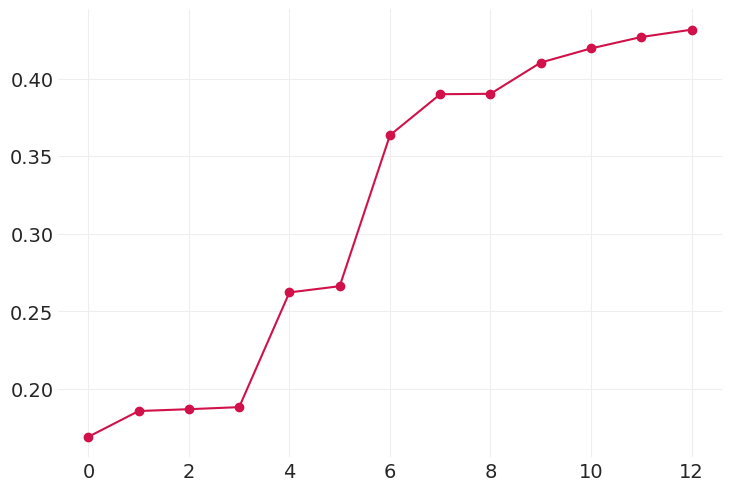

In [10]:
# convert dict to df
mse_df = pd.DataFrame(list(model_mse.items()), columns=["model_name", "mse"]).sort_values("mse").reset_index(drop=True)
mse_df["model_type"] = mse_df["model_name"].apply(lambda x: "Global Pooled CV" if x.endswith("__global_pooled_cv") else "Session CV")

# glocal_pooled_cv only
mse_df = mse_df[mse_df["model_type"] == "Global Pooled CV"]

plt.plot(mse_df.index, mse_df["mse"], "o-")

mse_df

## Final Model

In [11]:
selected_model = mse_df["model_name"].iloc[0]
print(f"Selected model: {selected_model}")

Selected model: no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv


Processing no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv:   0%|          | 0/5 [00:00<?, ?i…

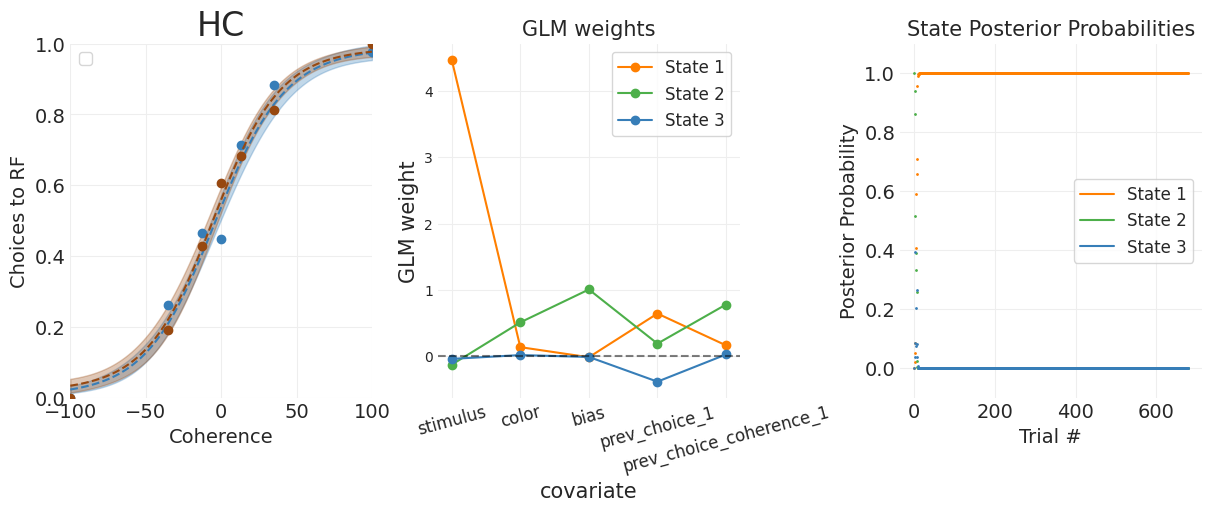

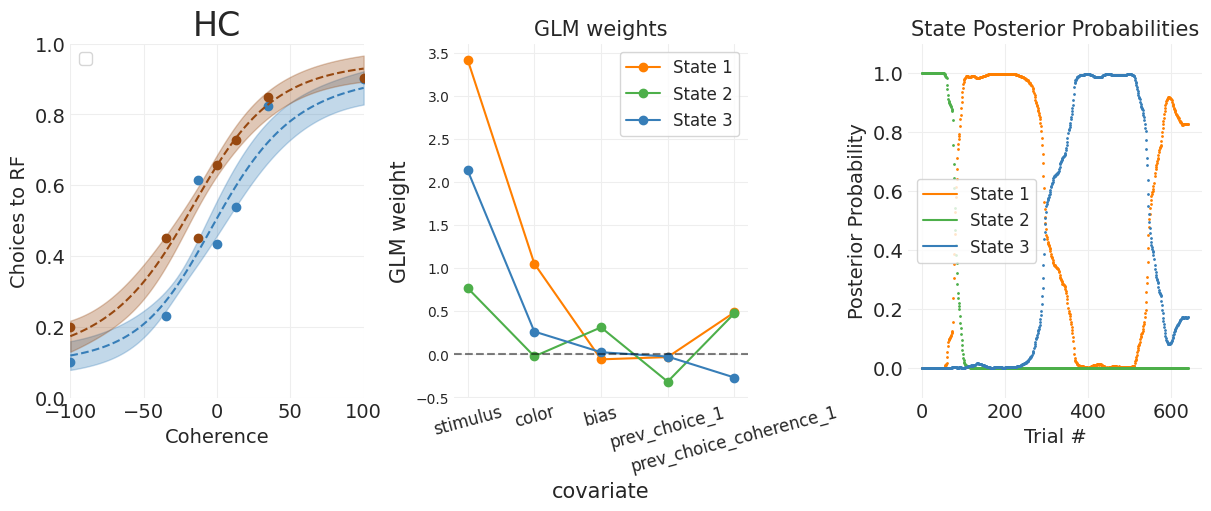

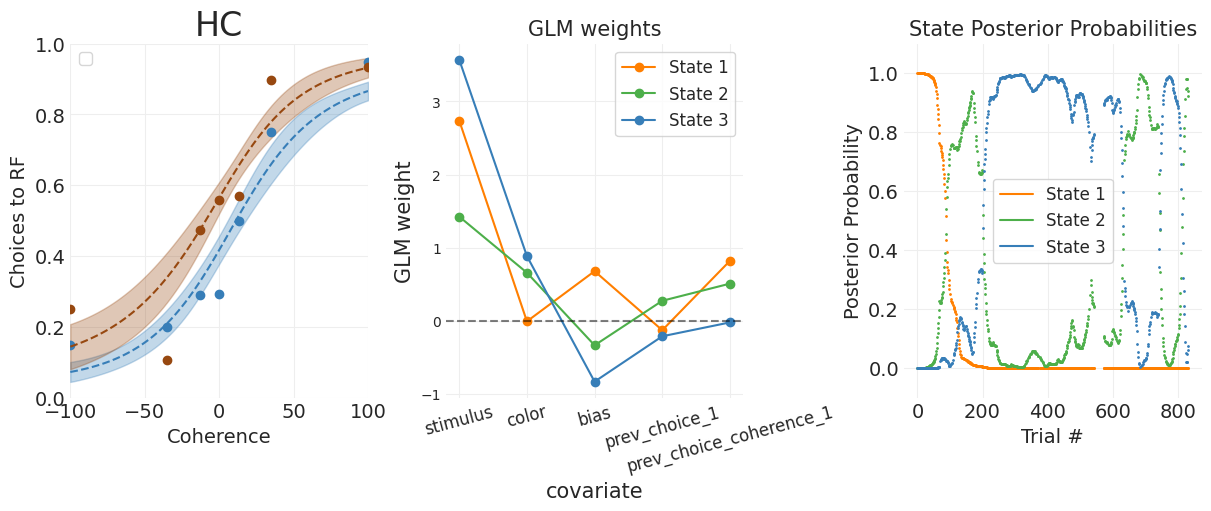

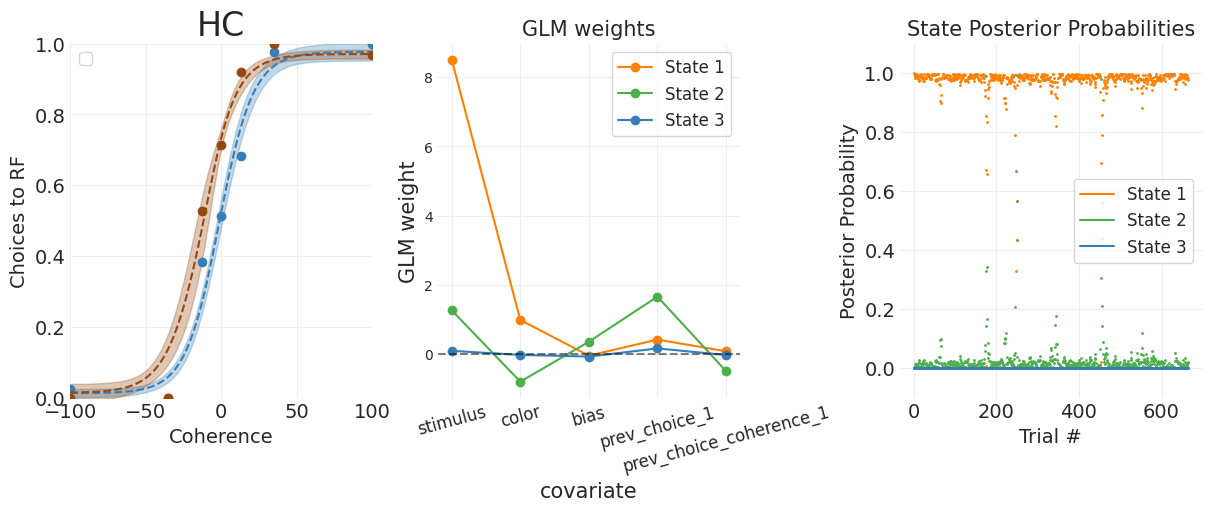

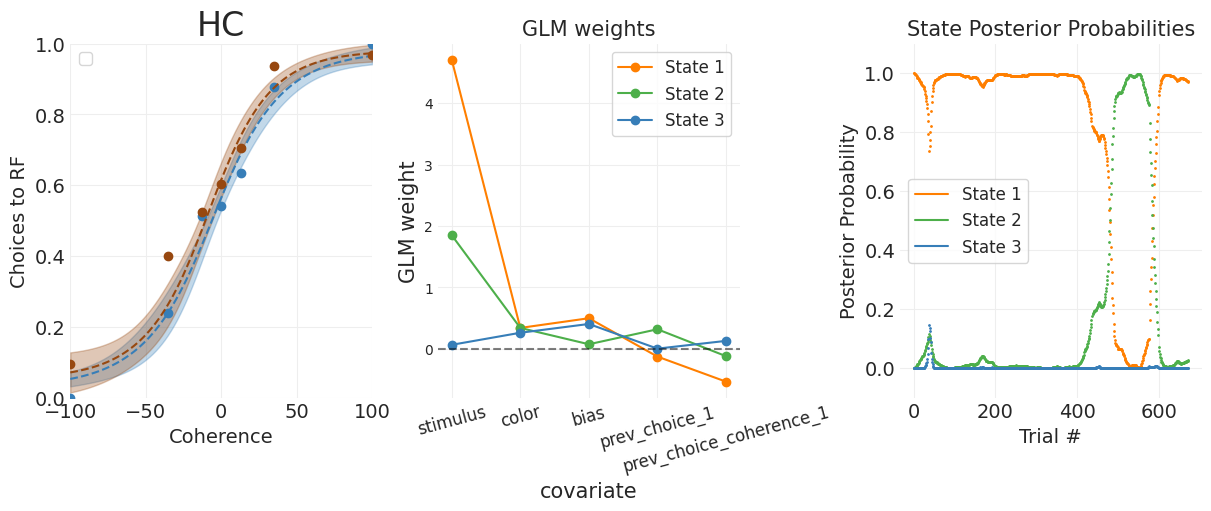

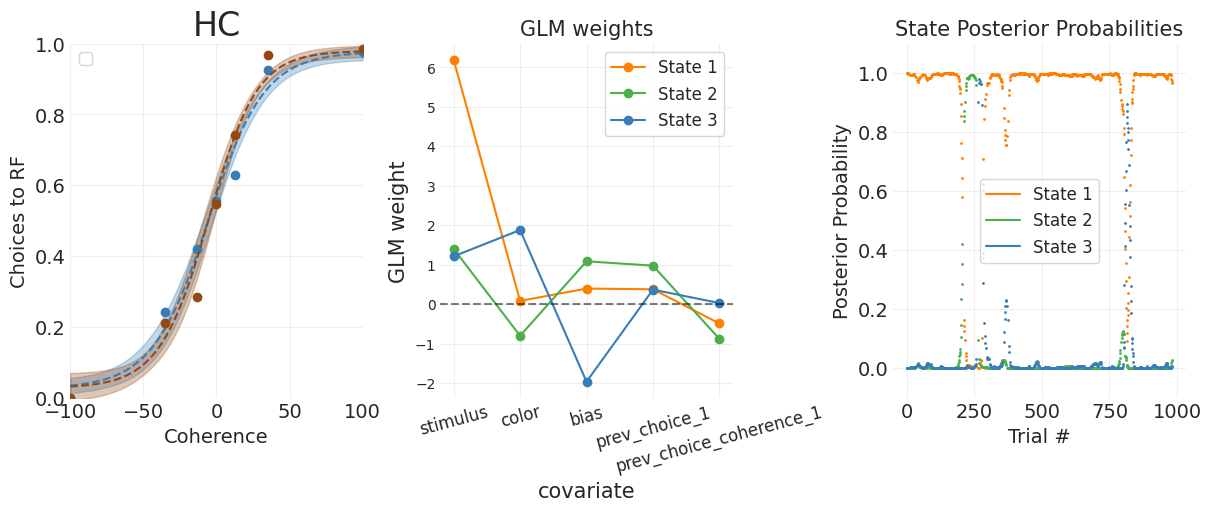

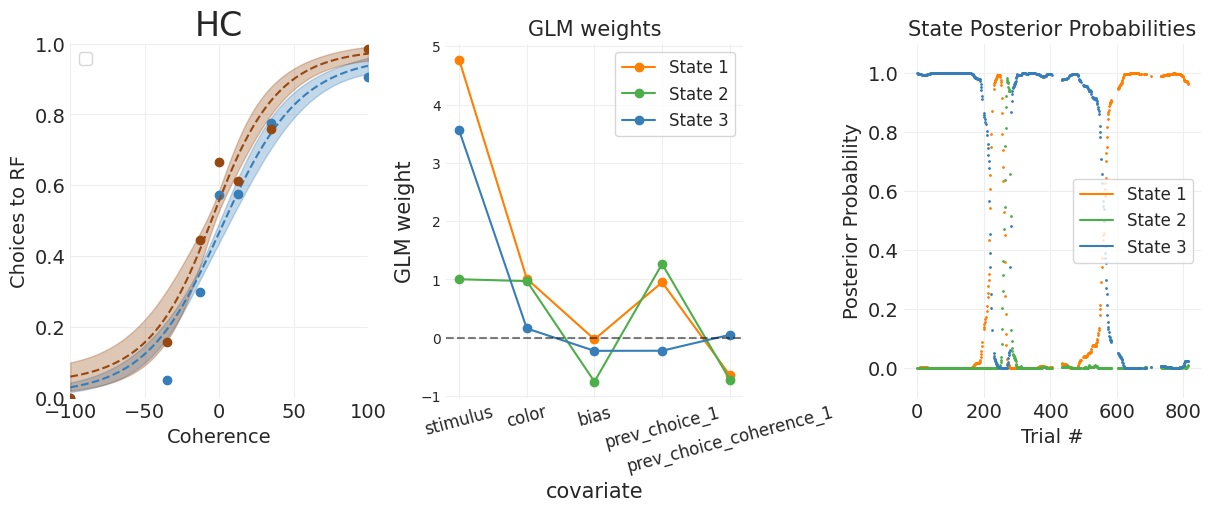

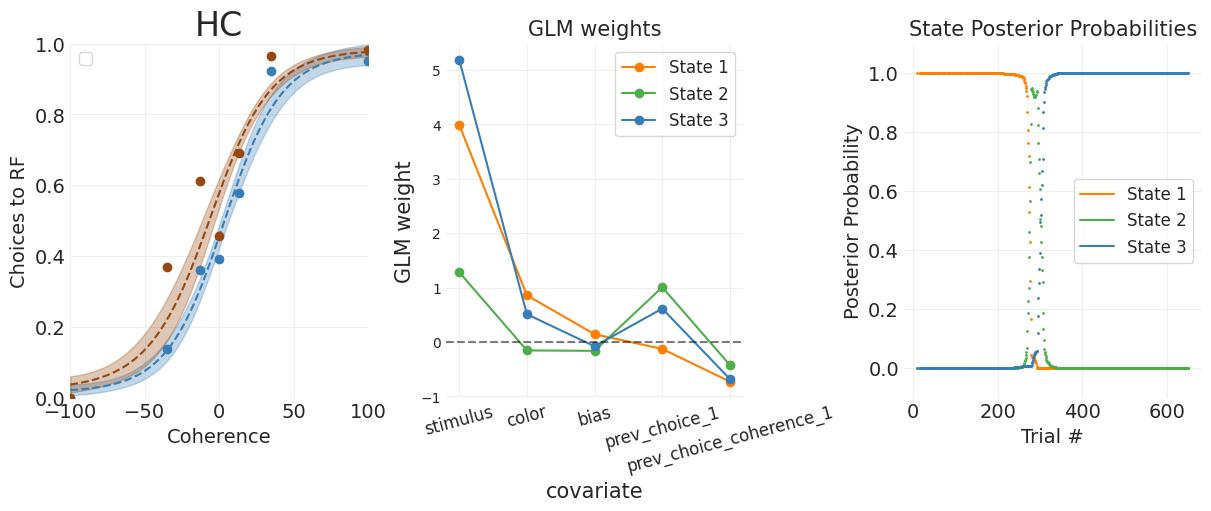

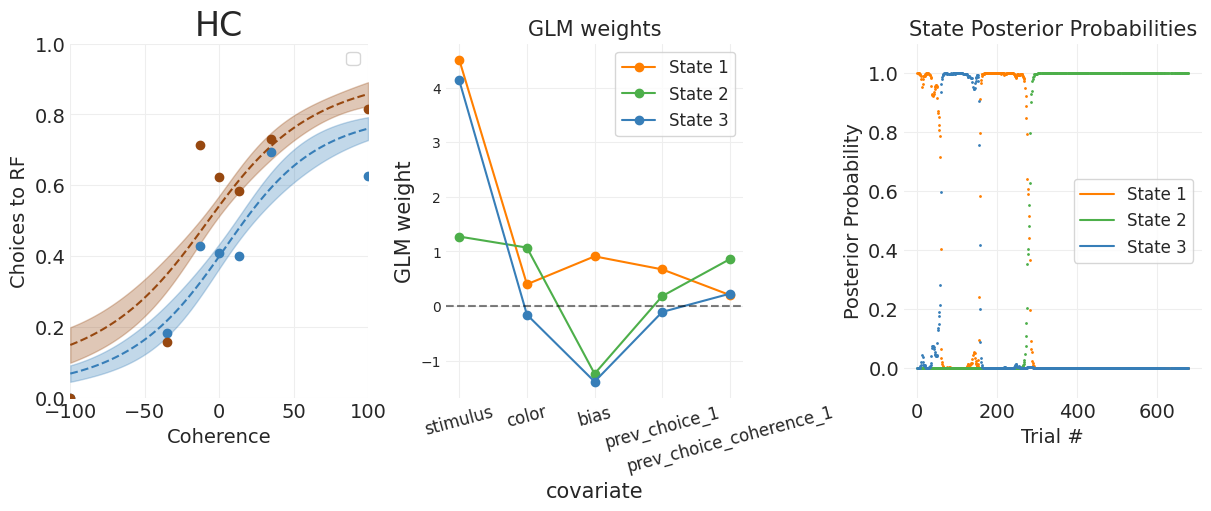

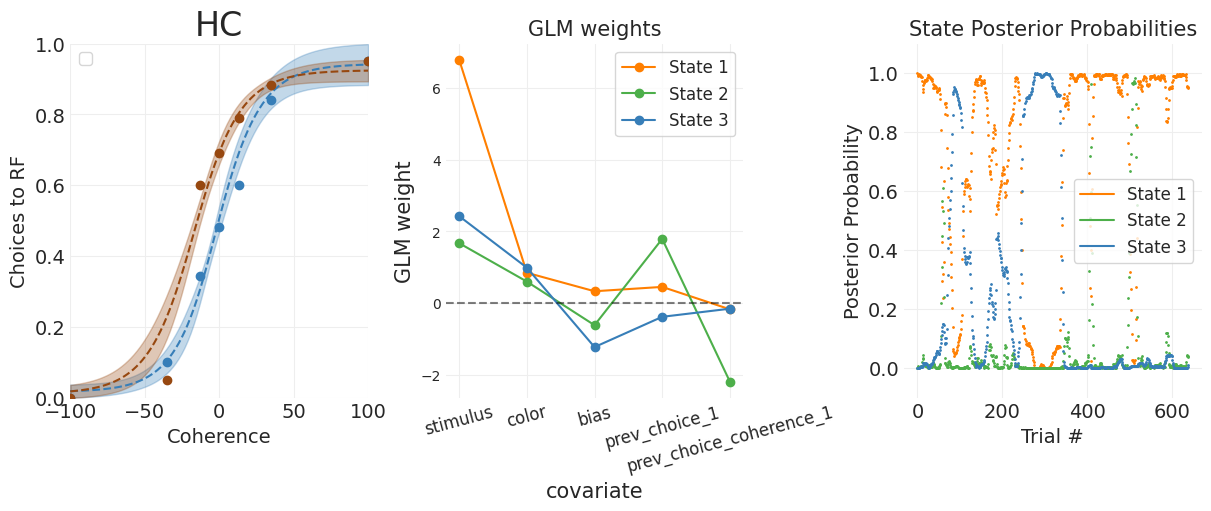

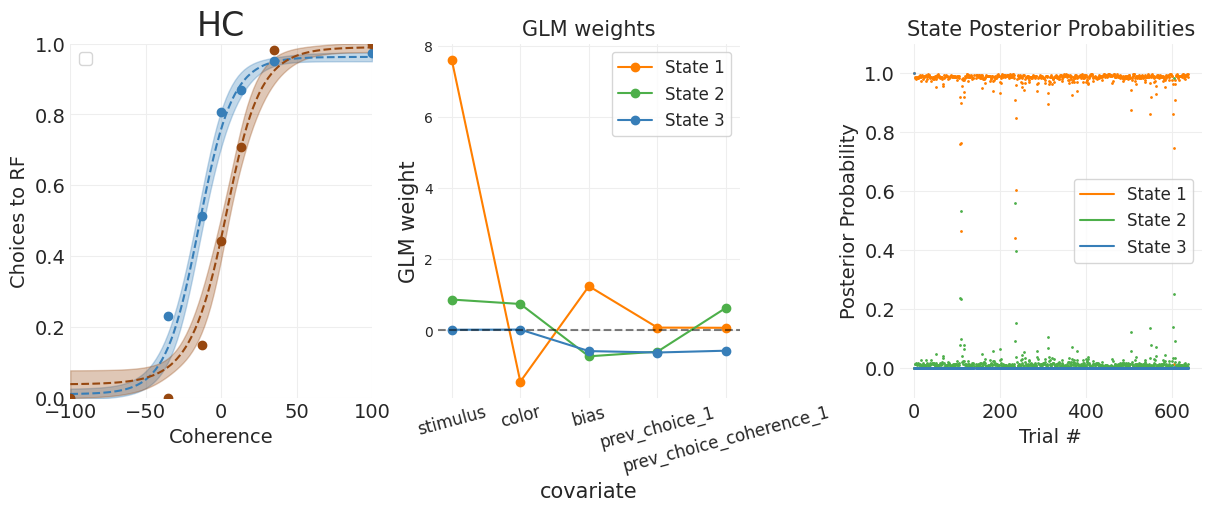

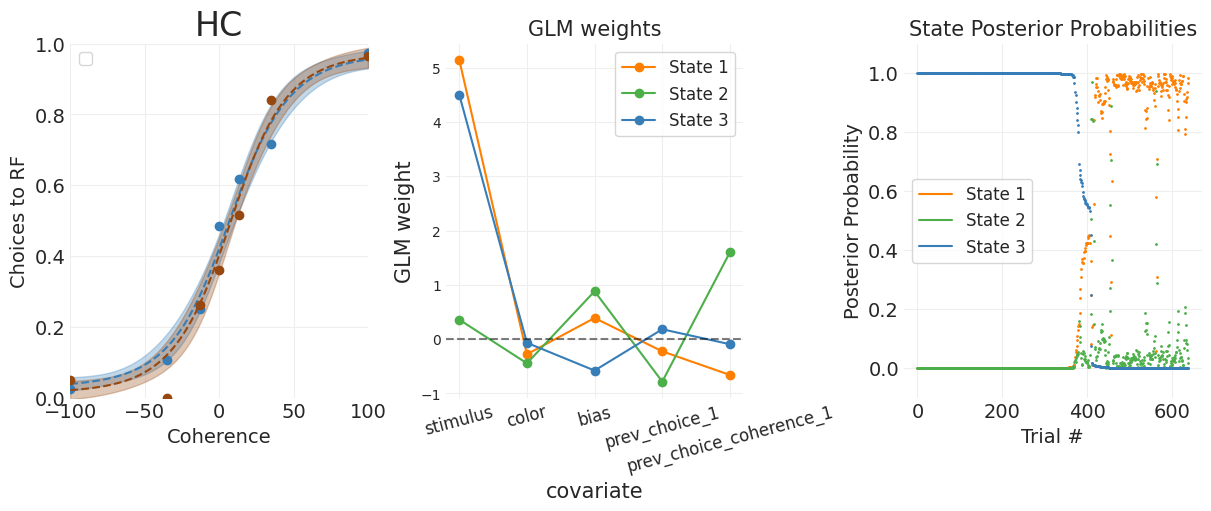

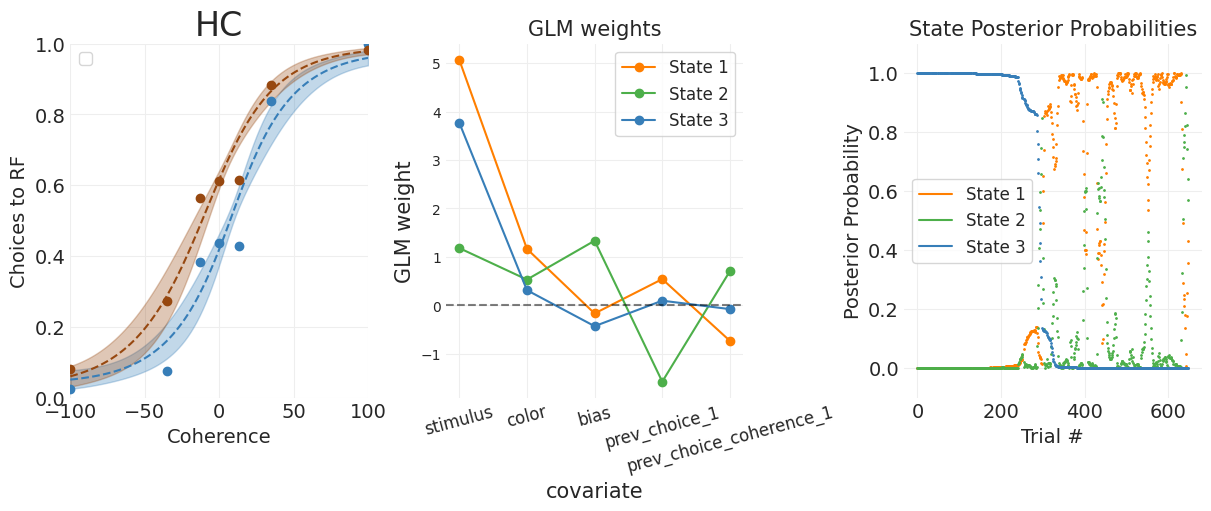

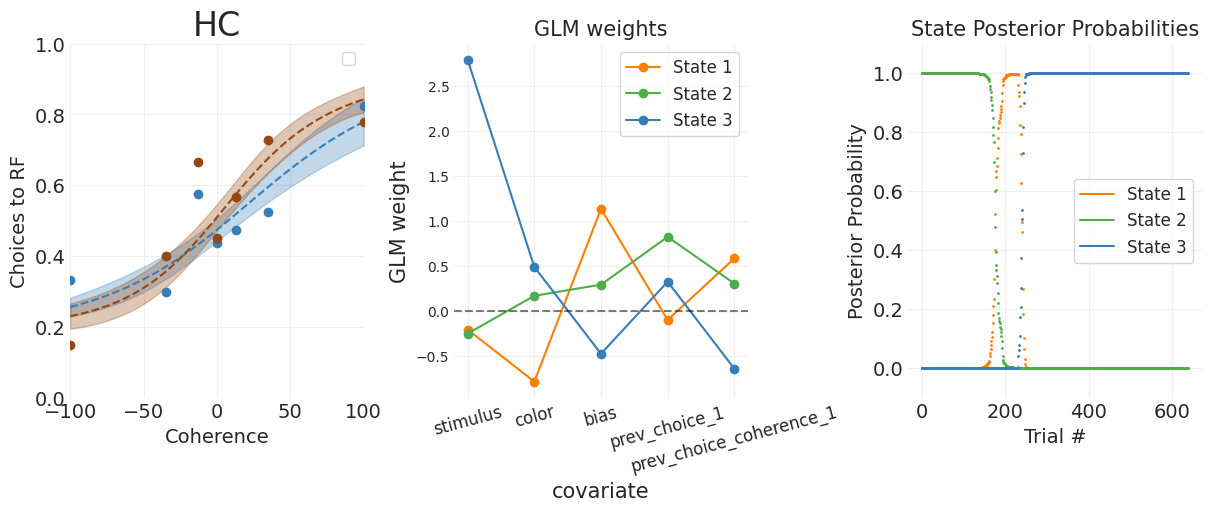

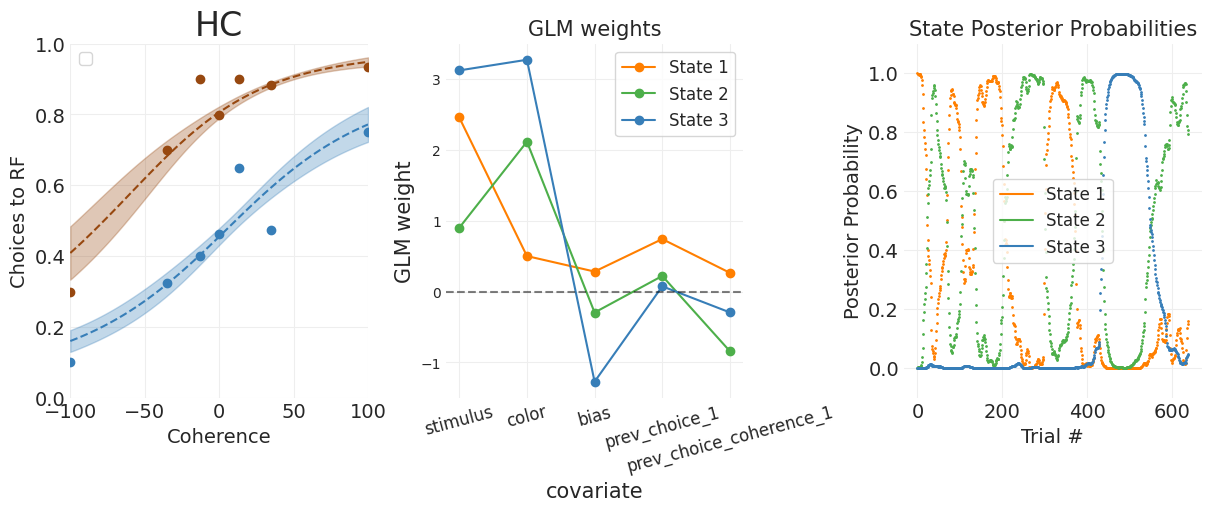

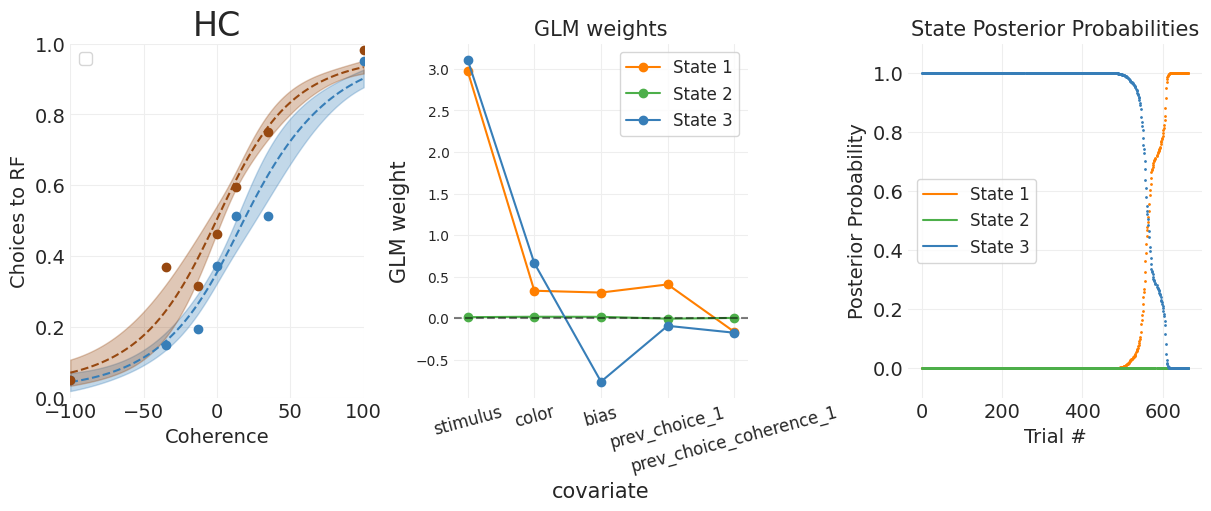

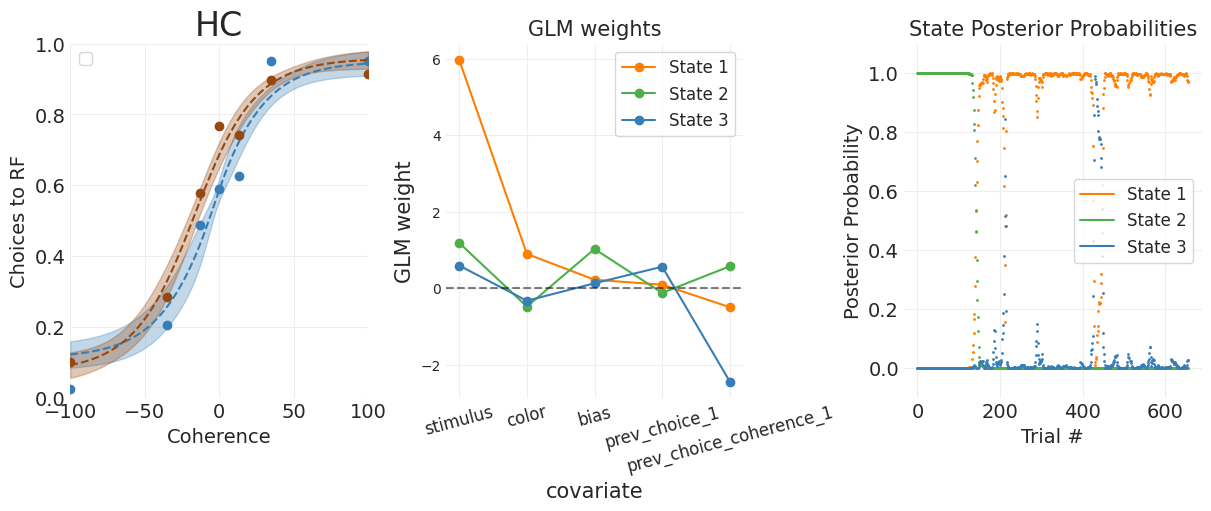

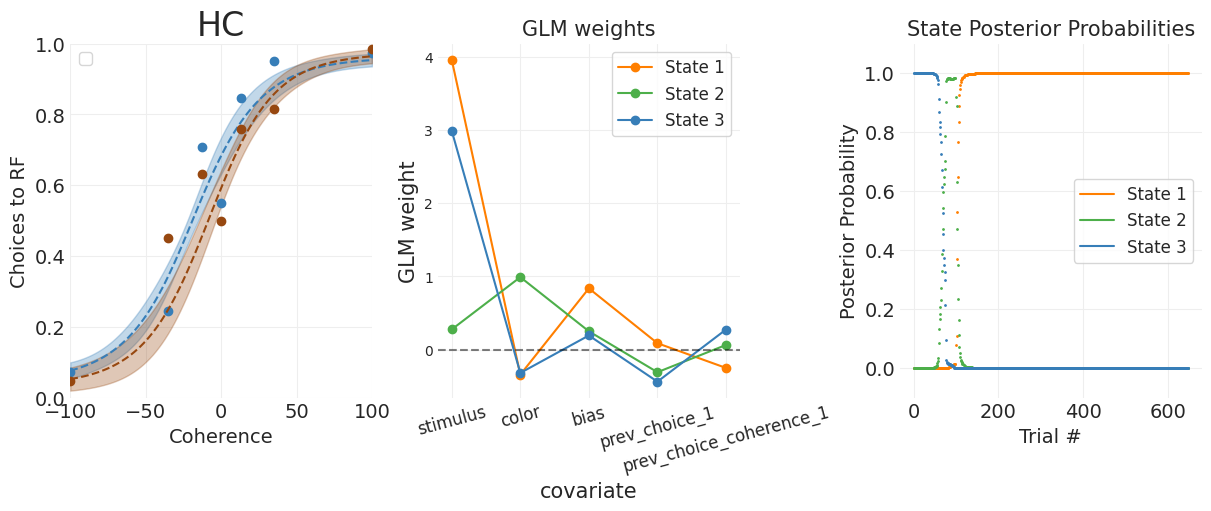

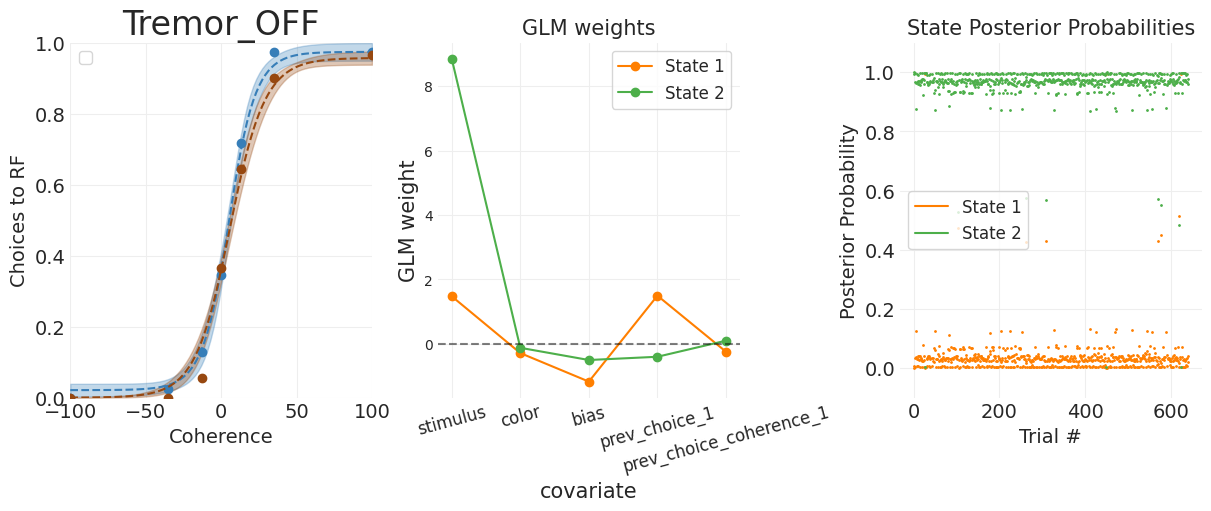

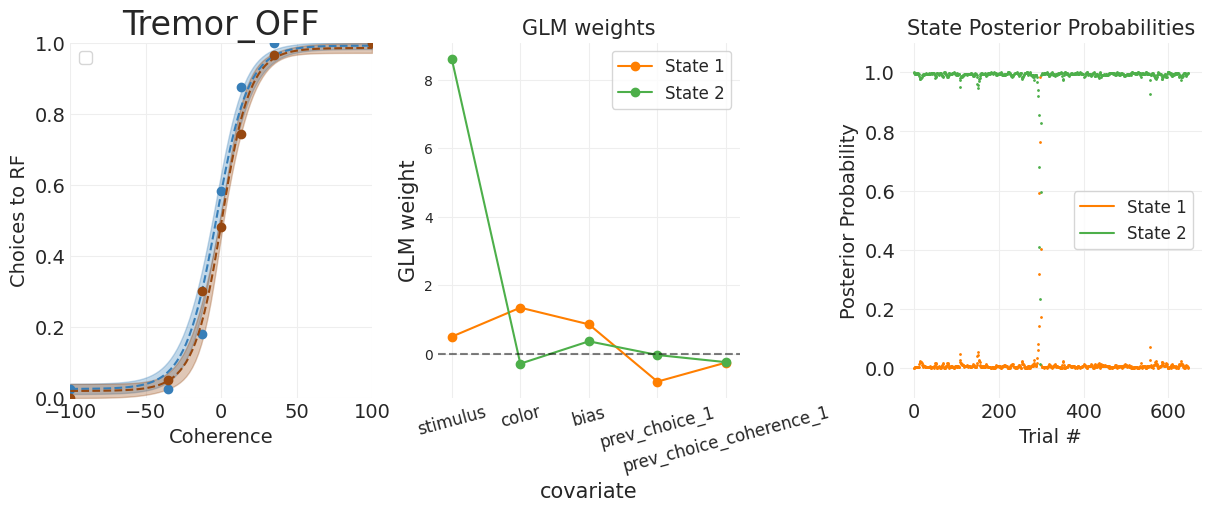

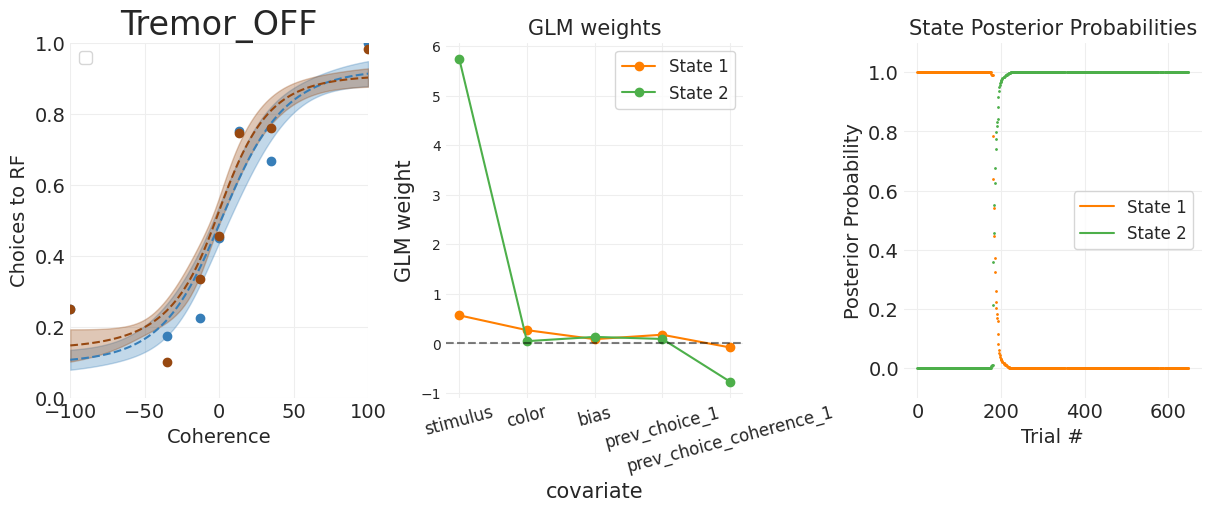

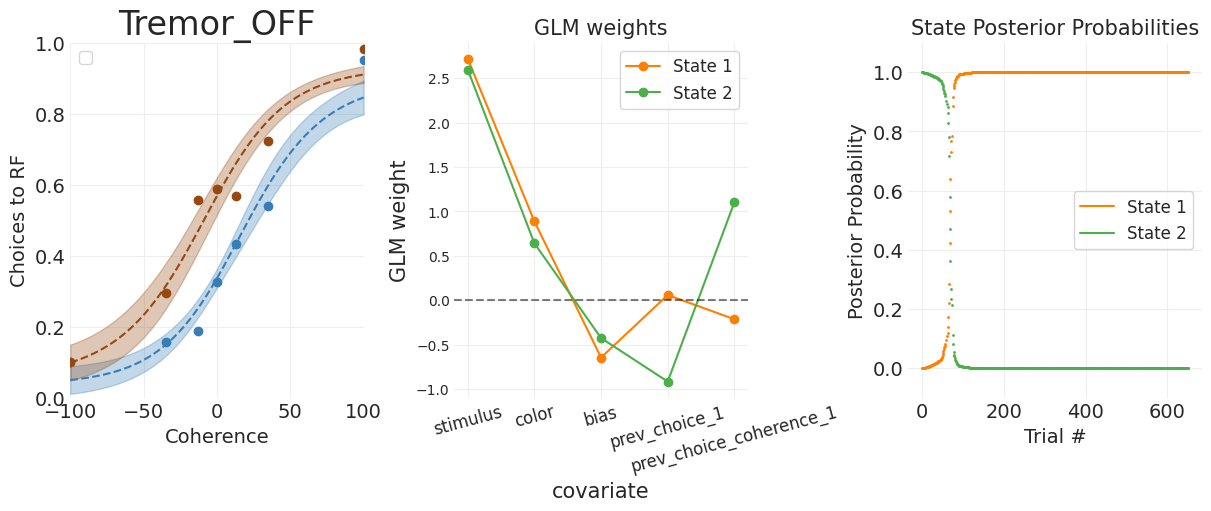

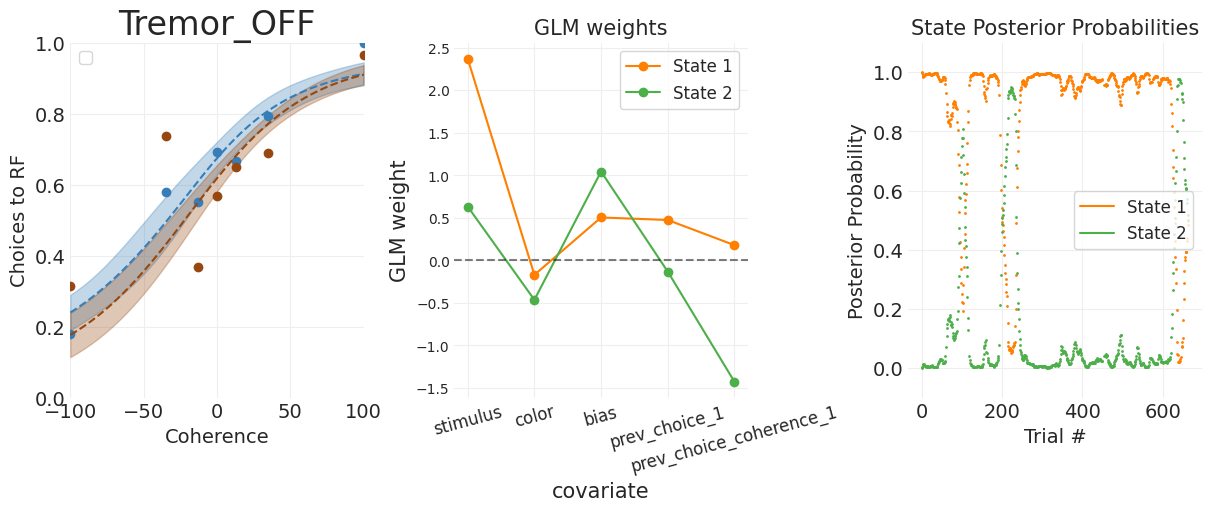

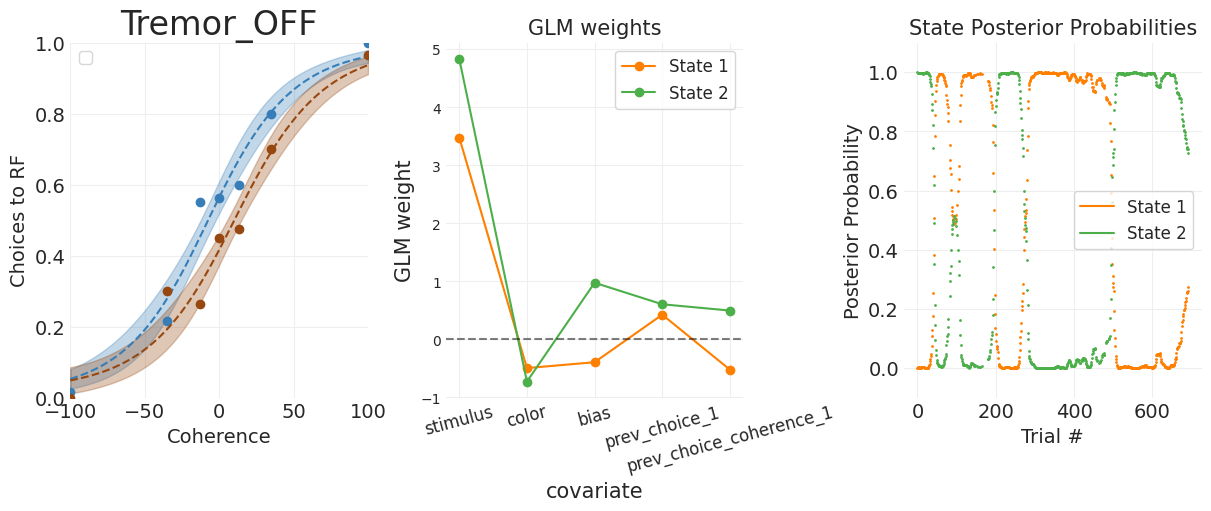

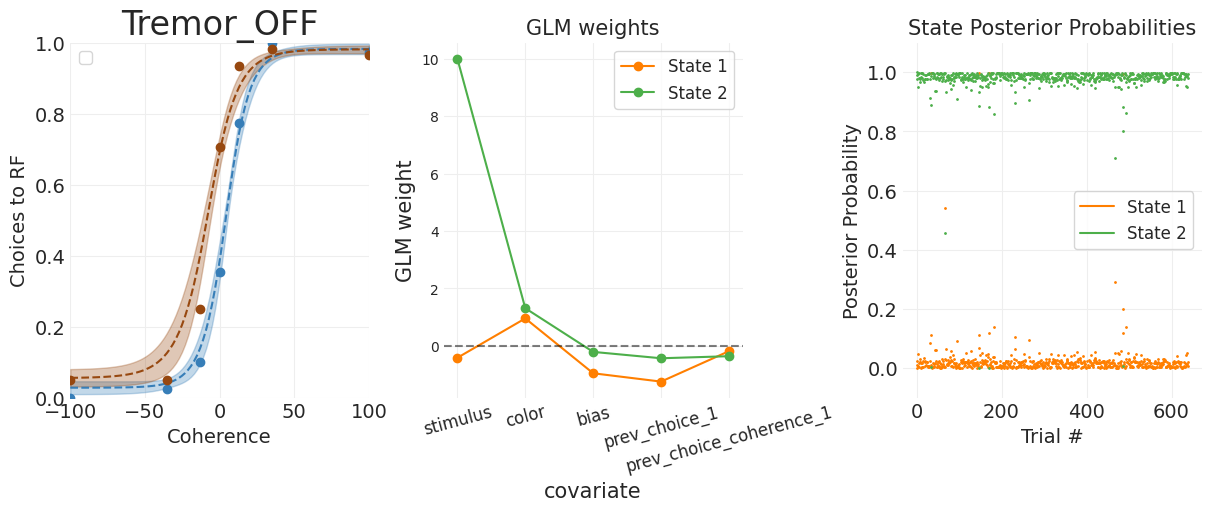

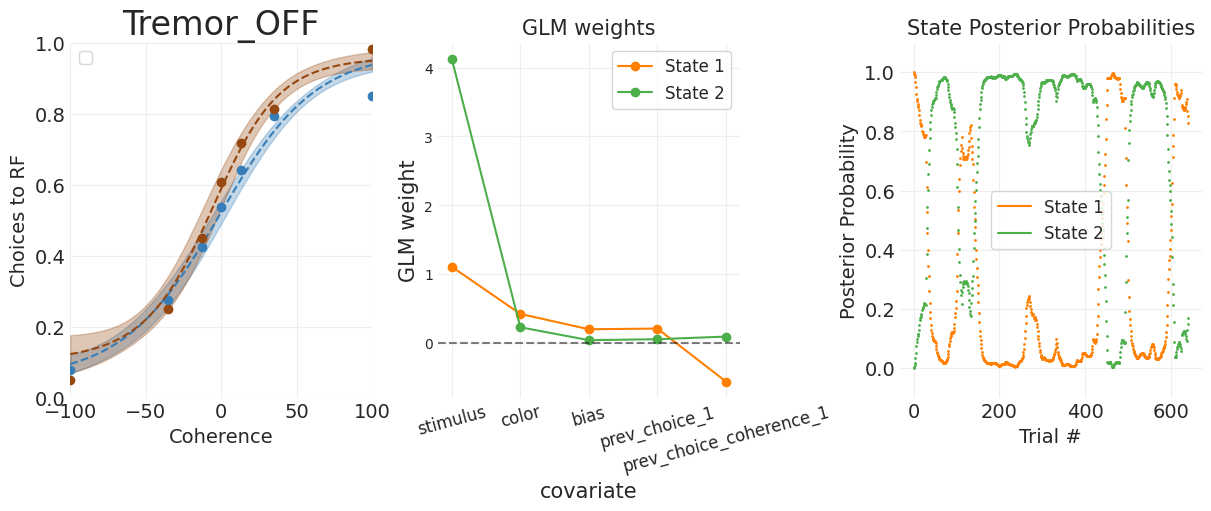

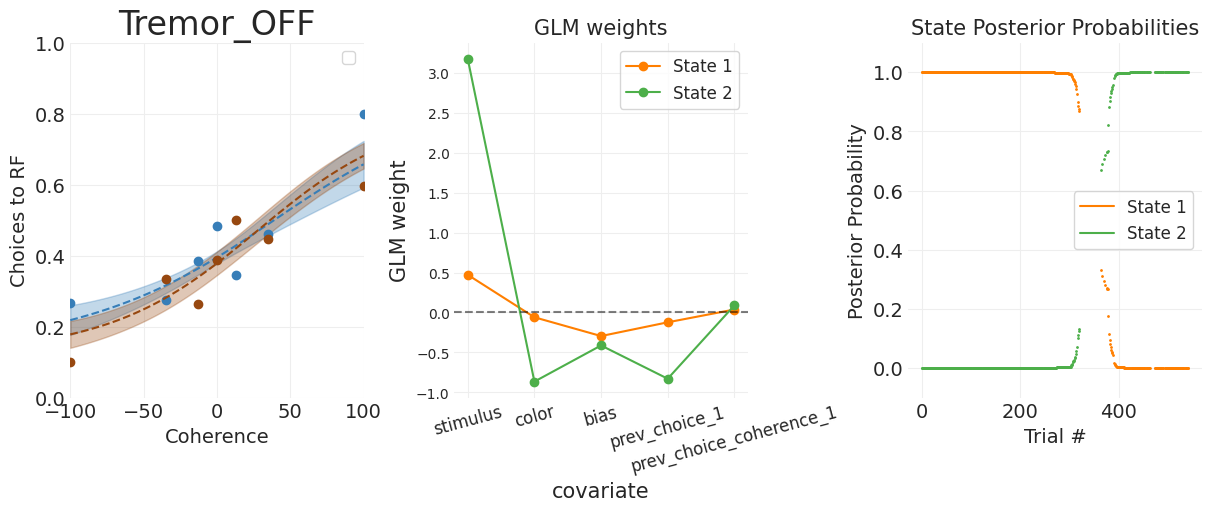

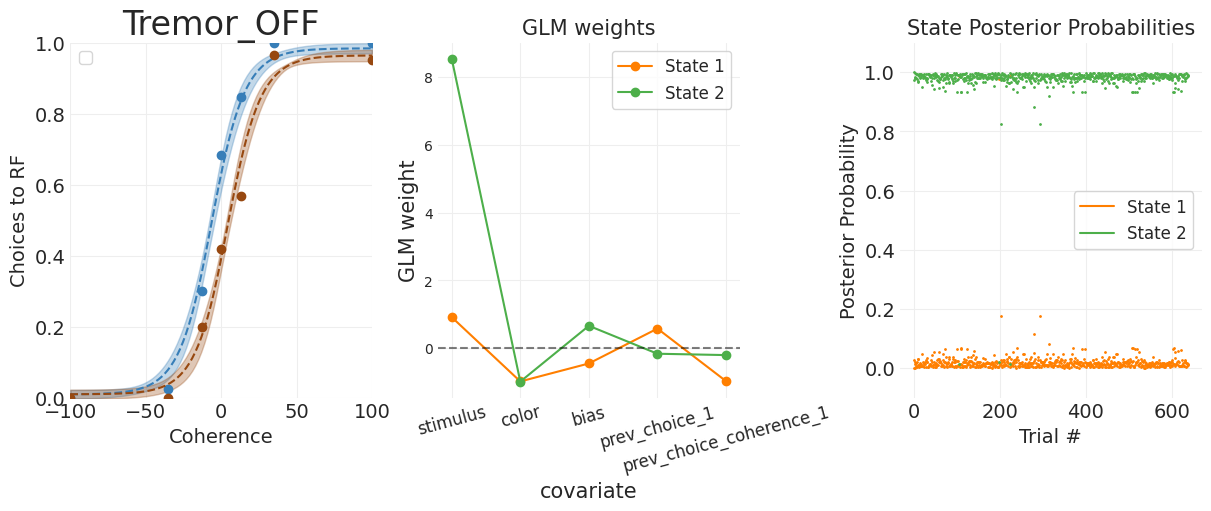

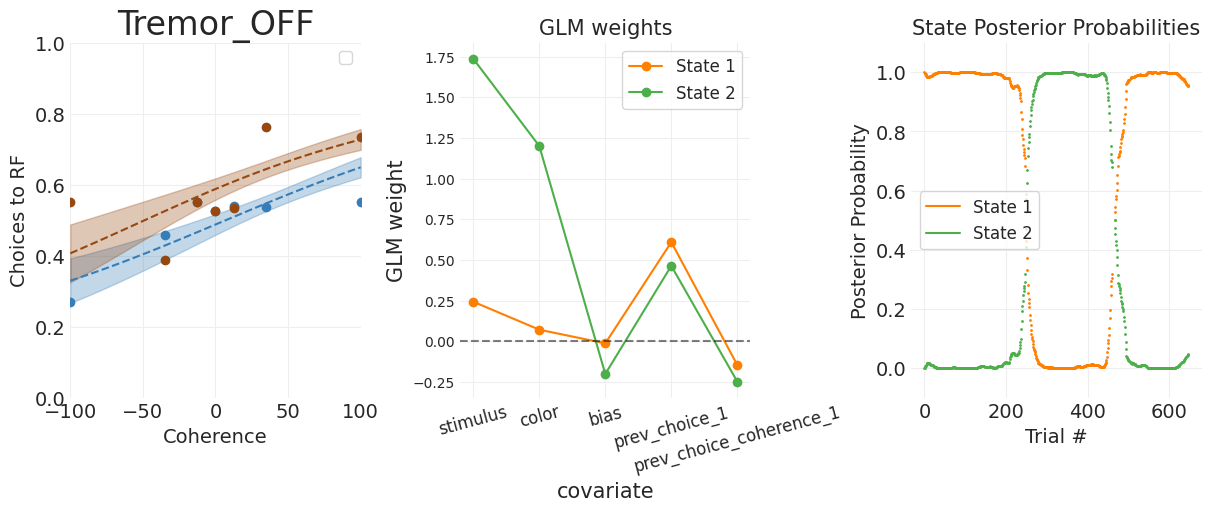

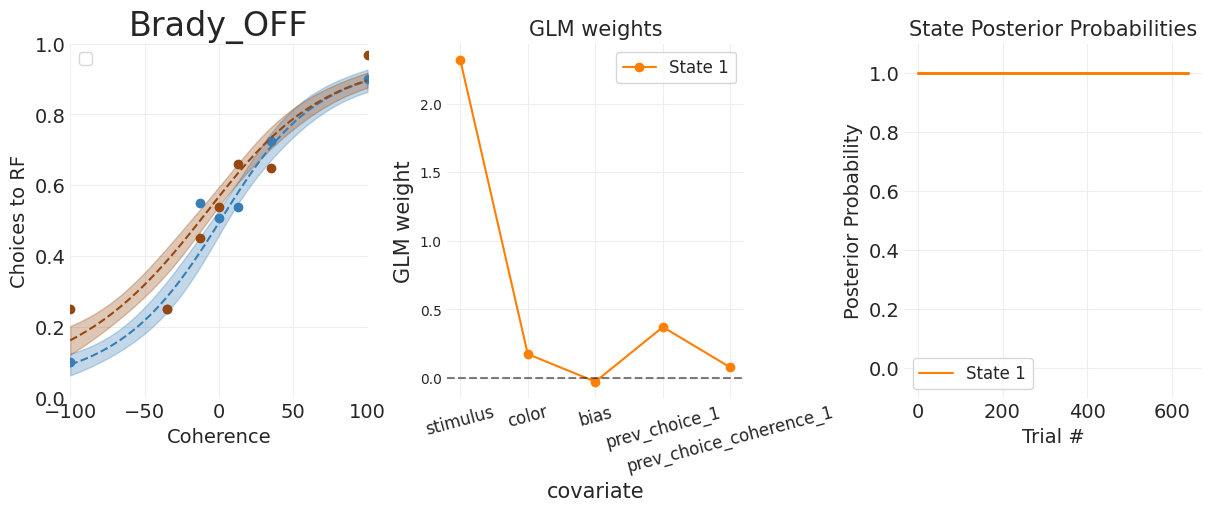

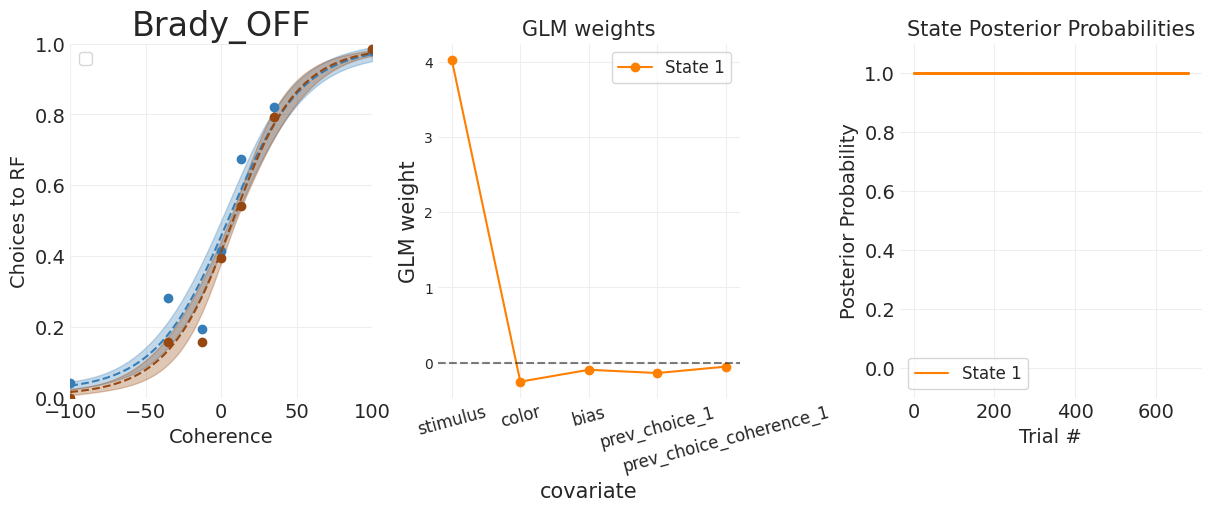

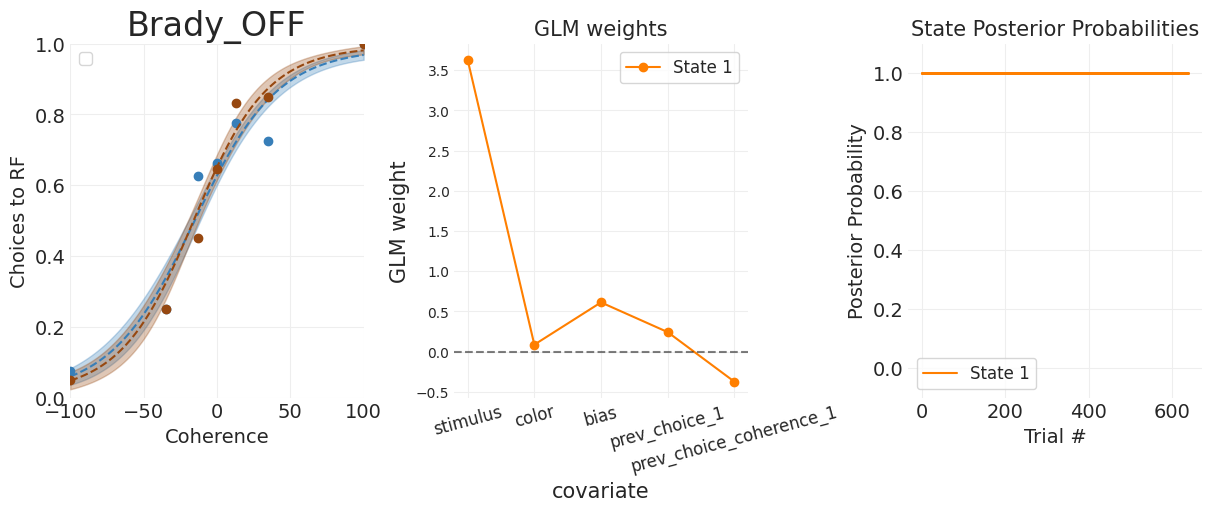

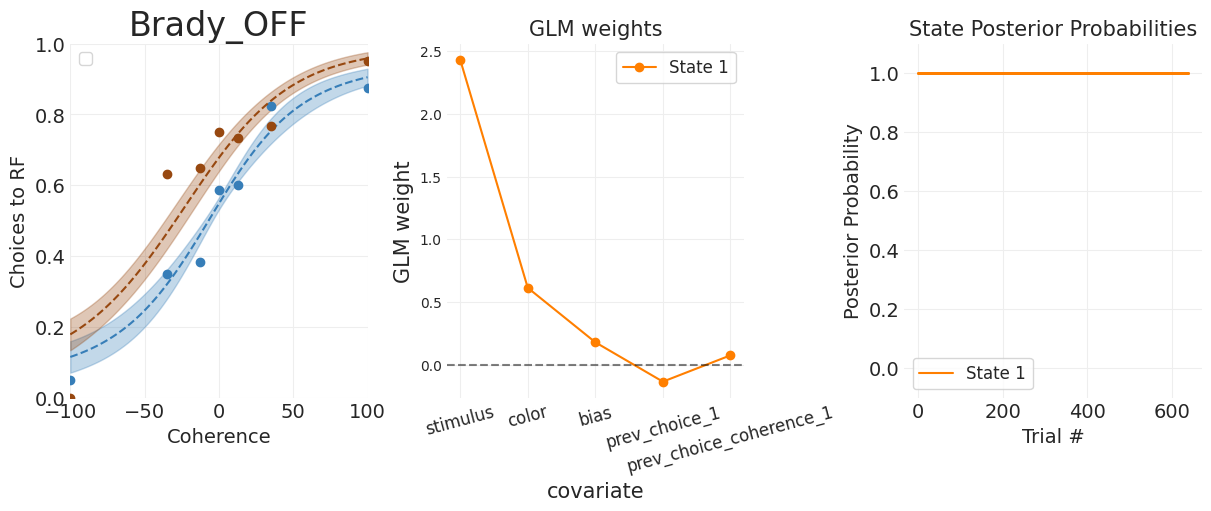

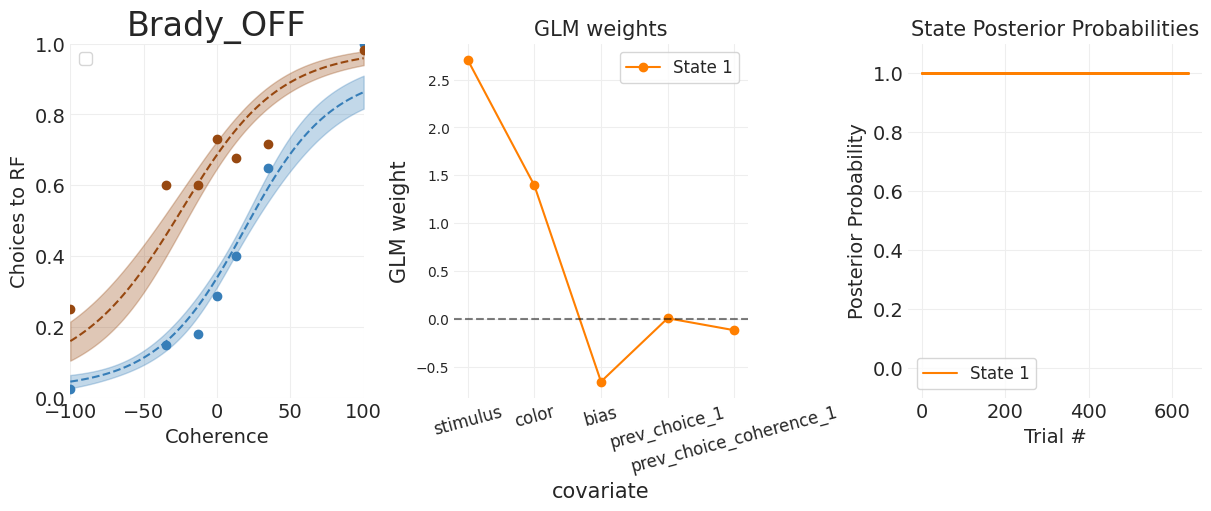

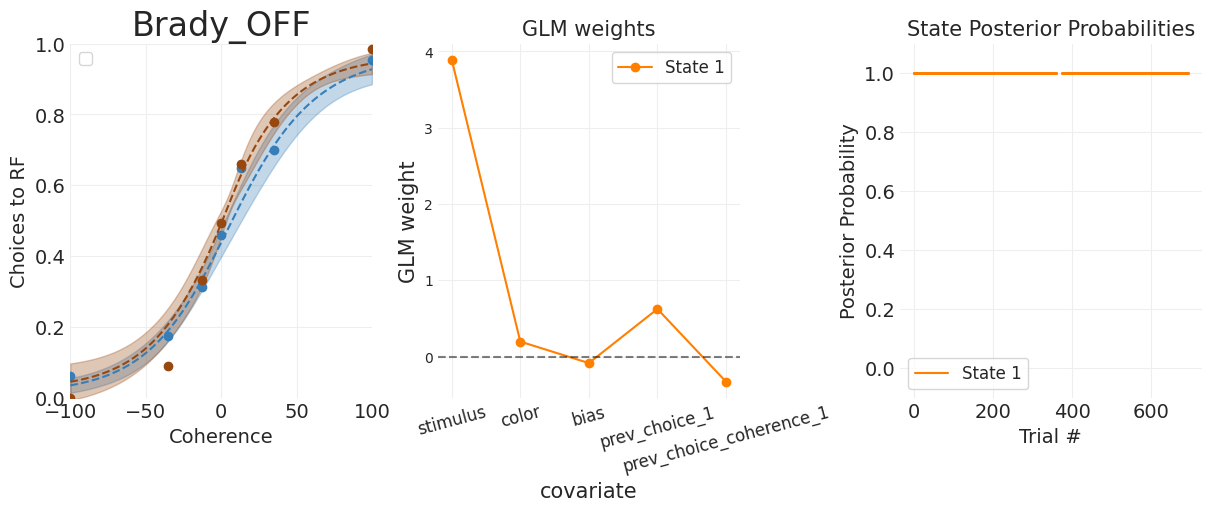

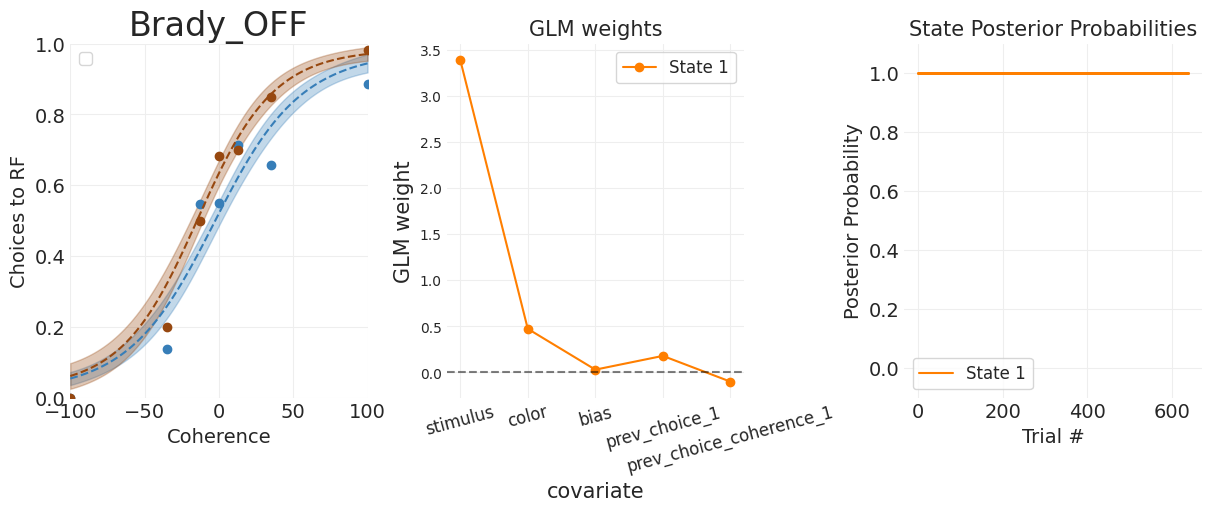

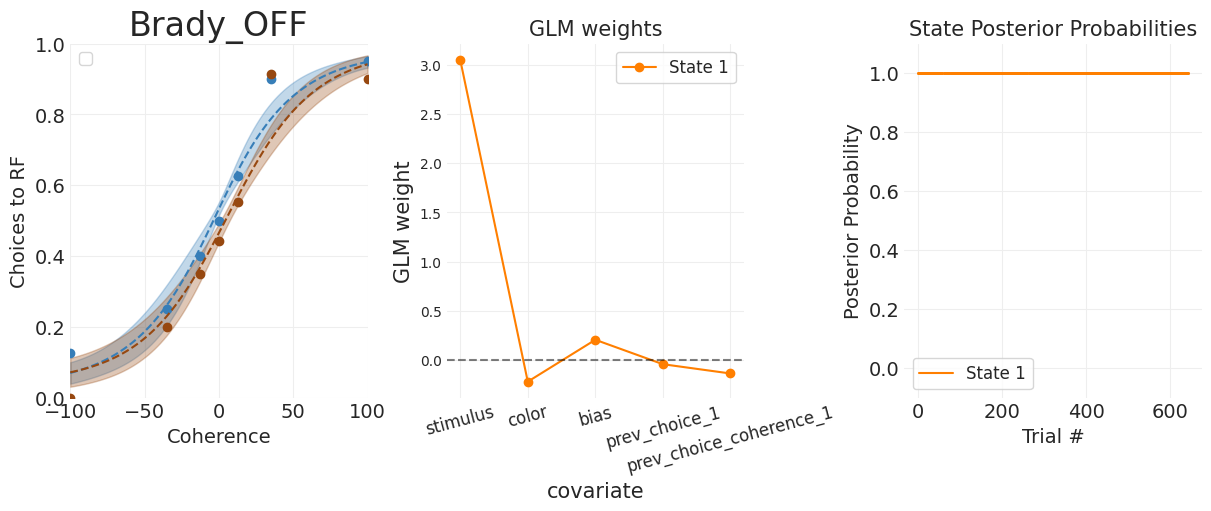

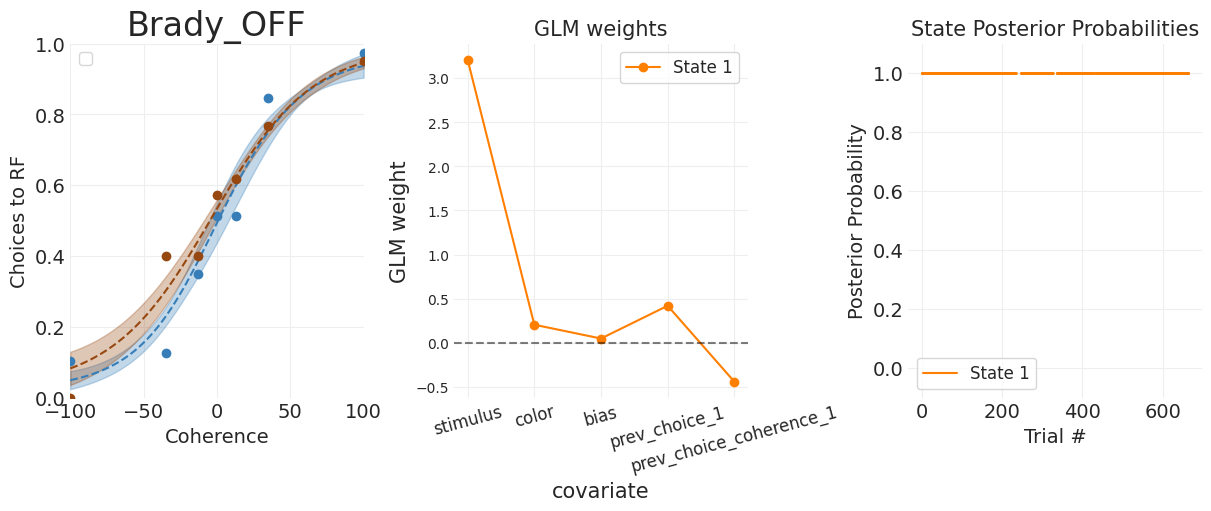

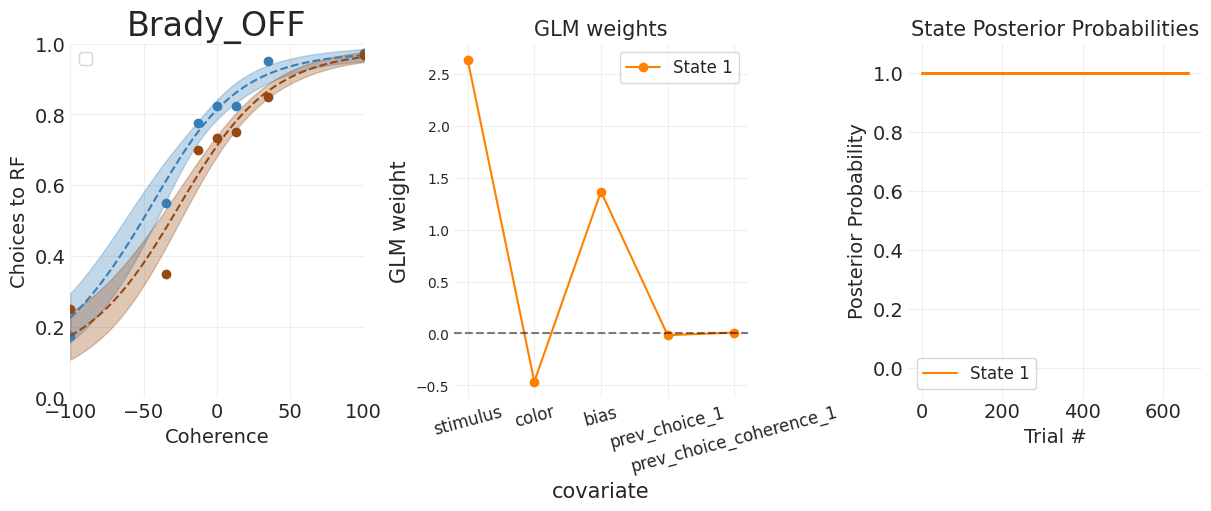

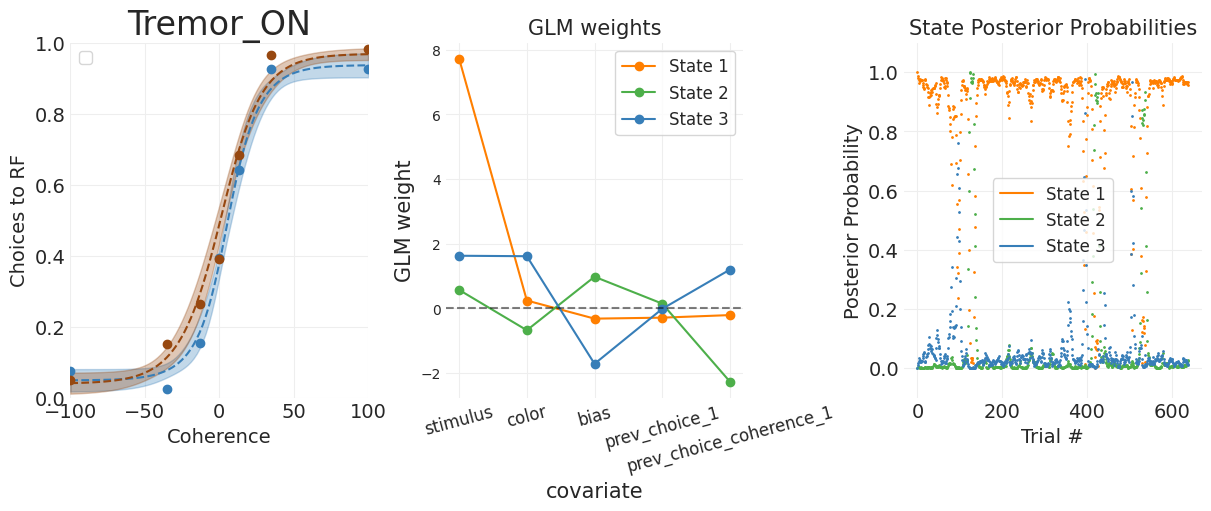

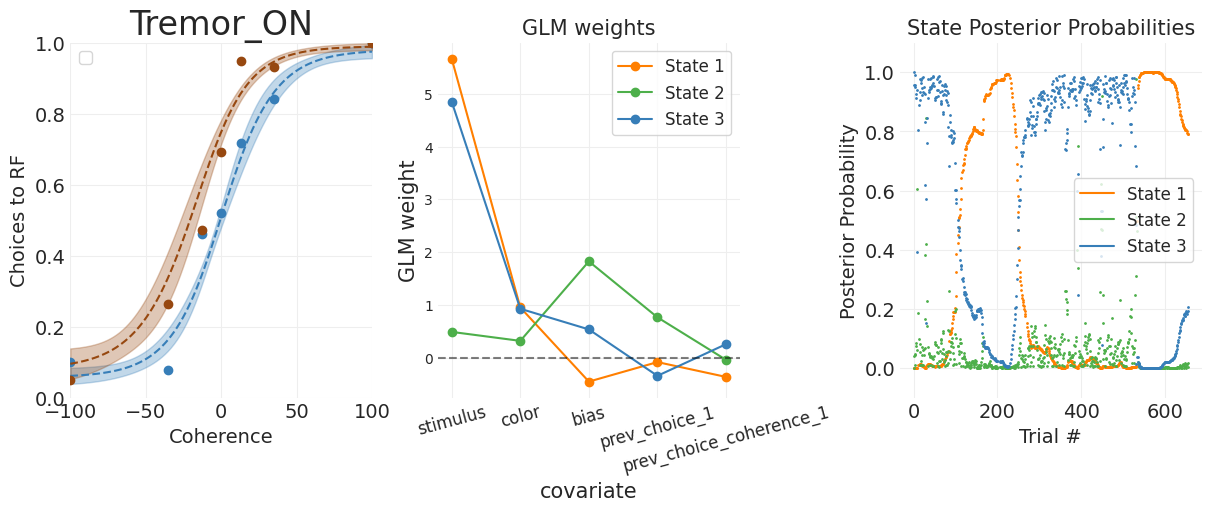

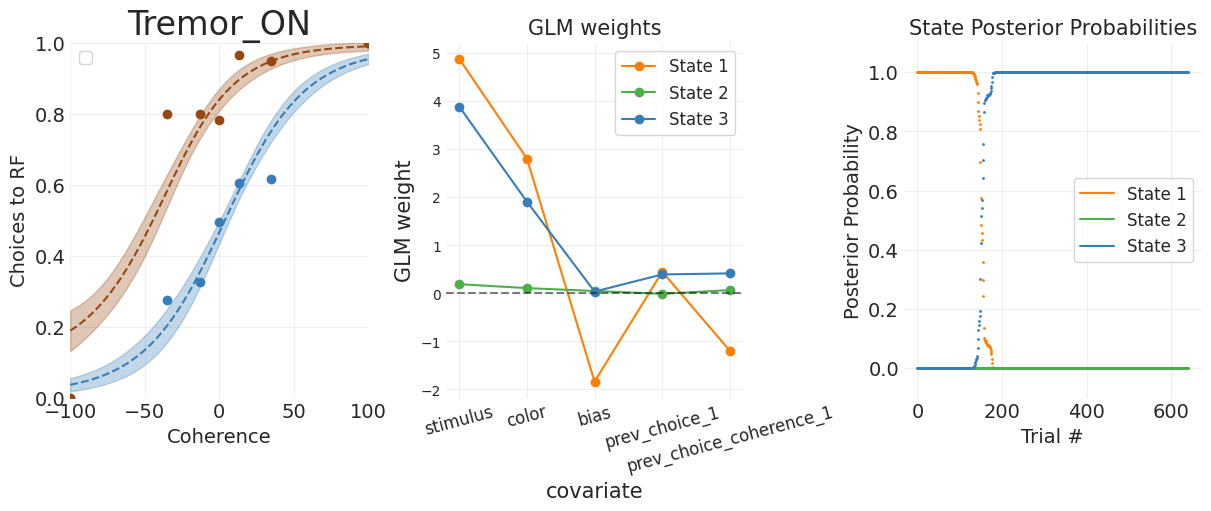

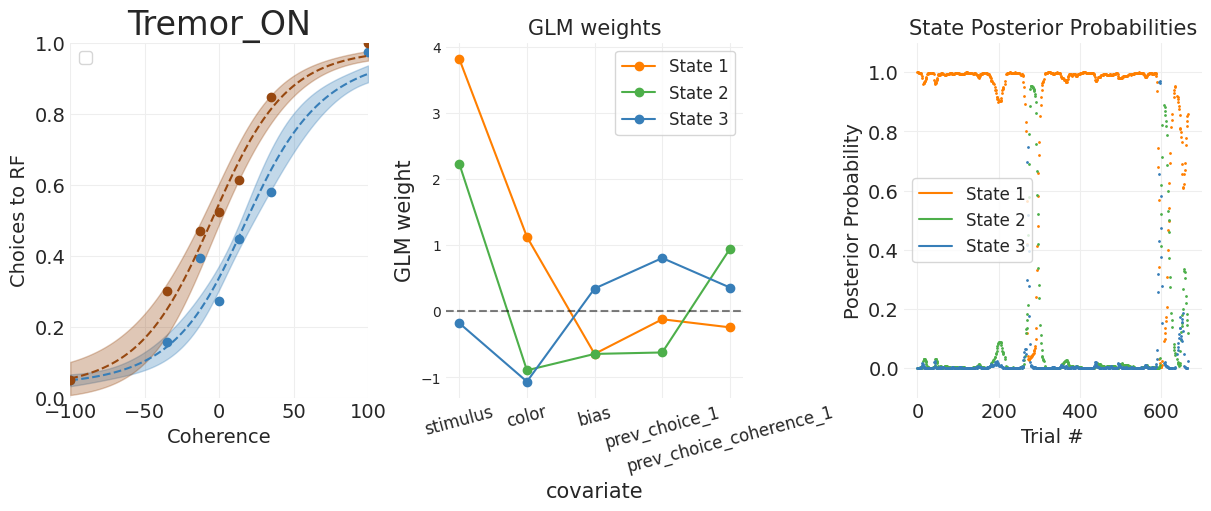

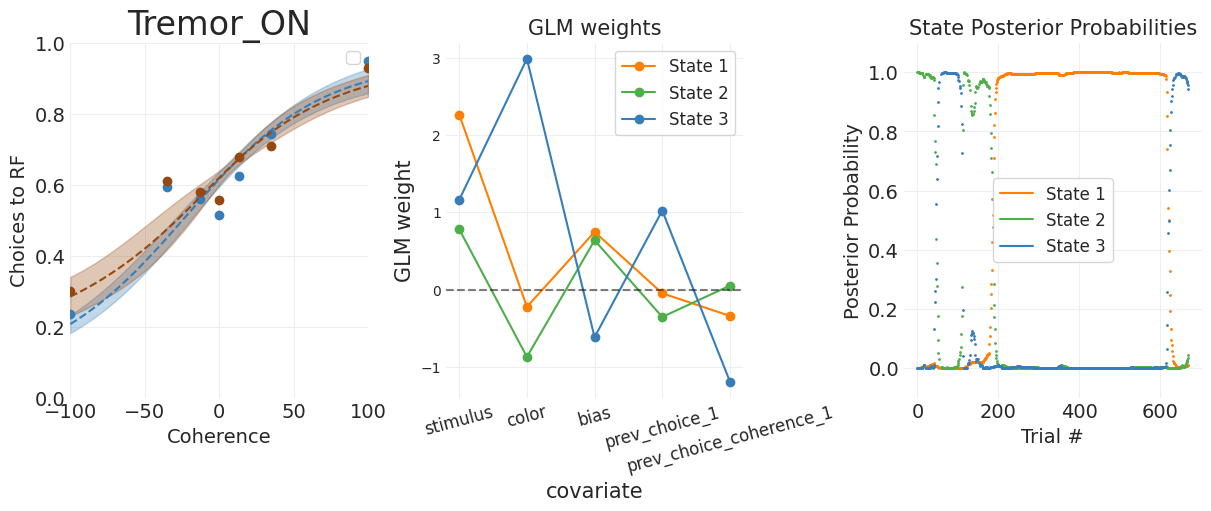

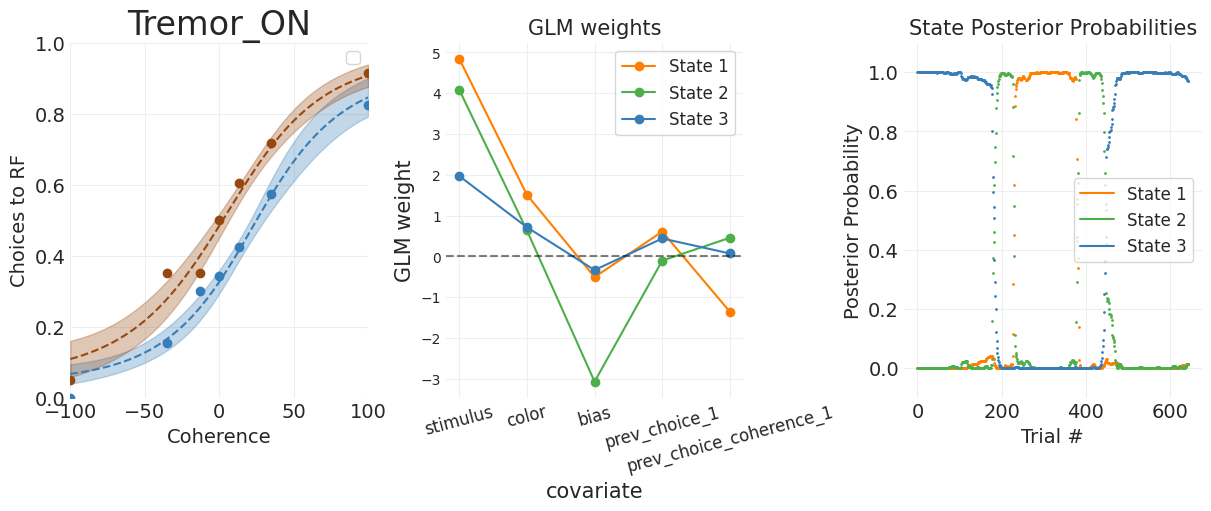

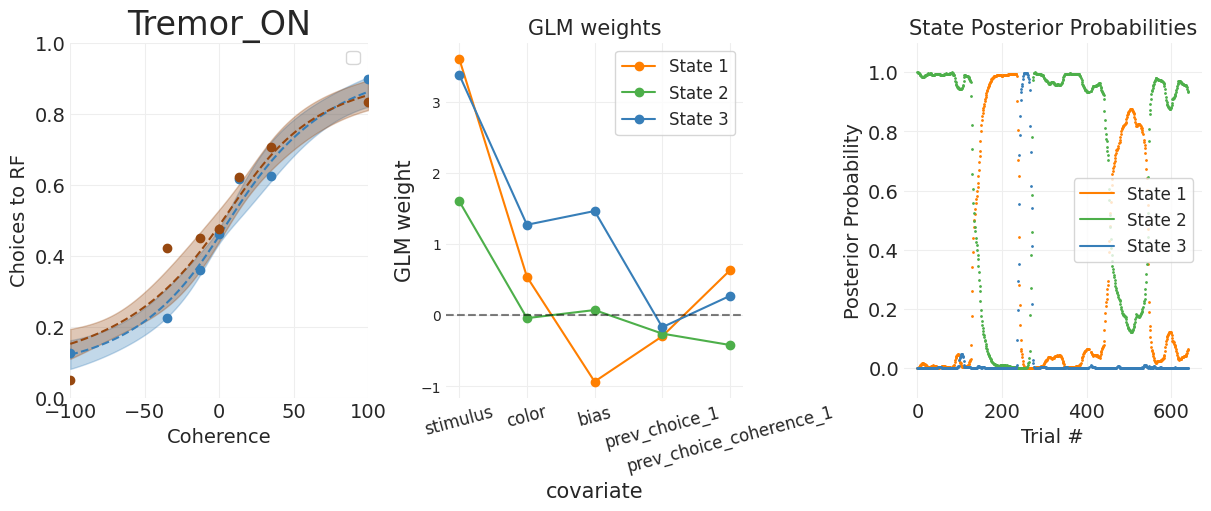

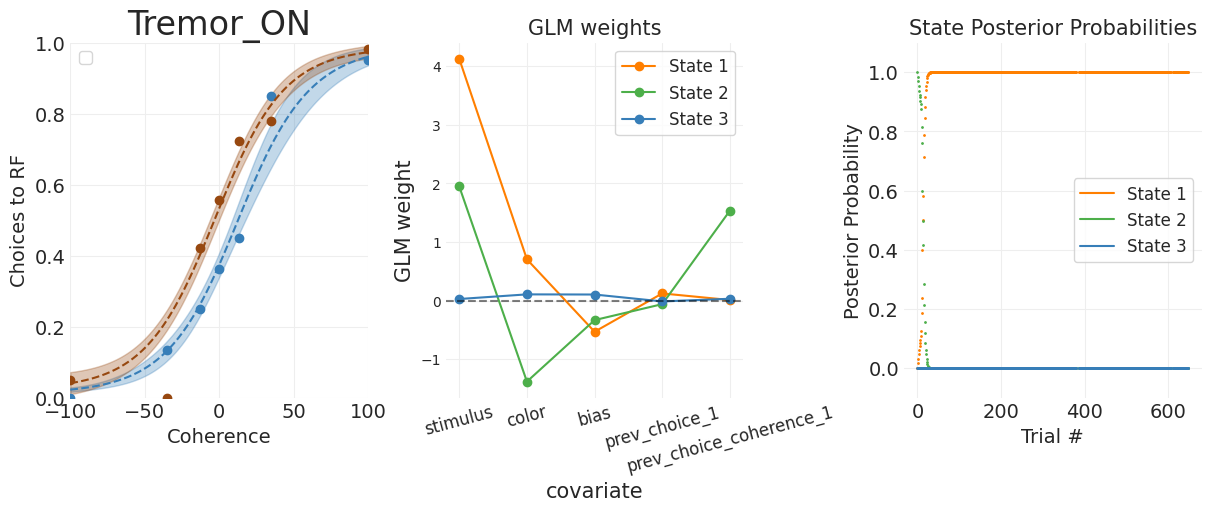

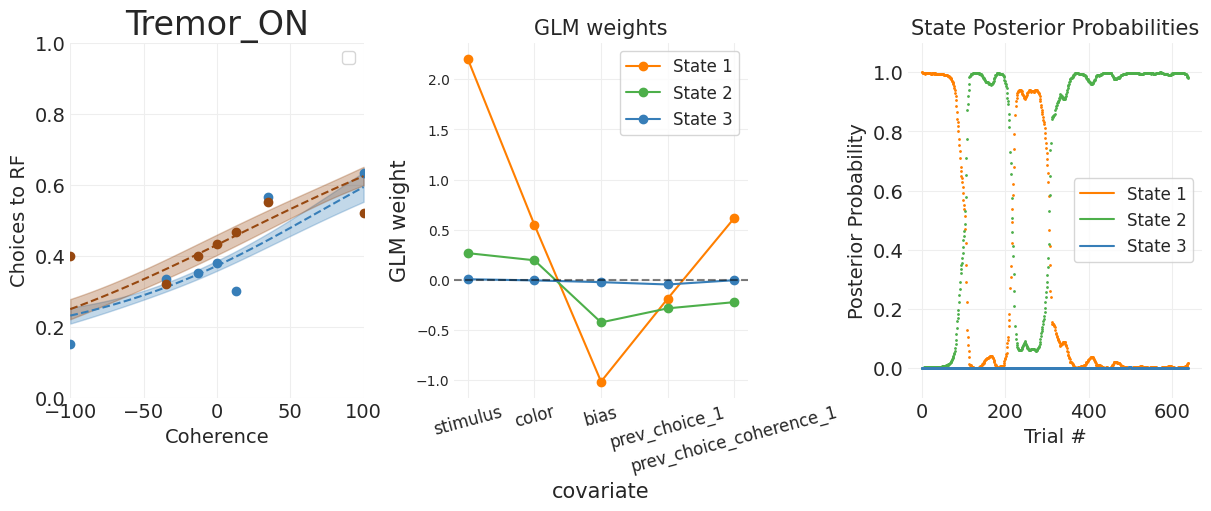

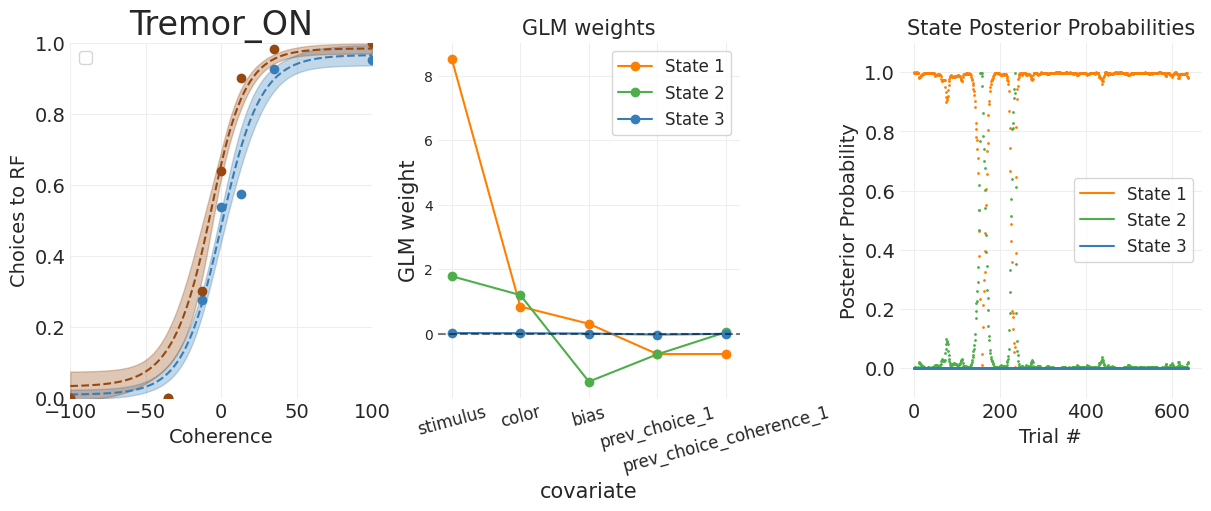

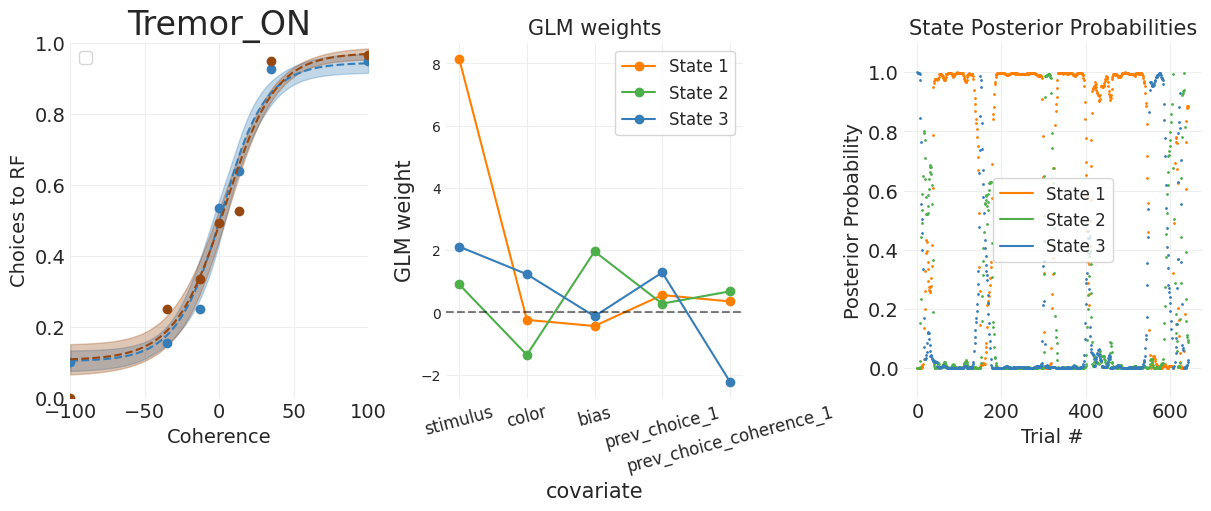

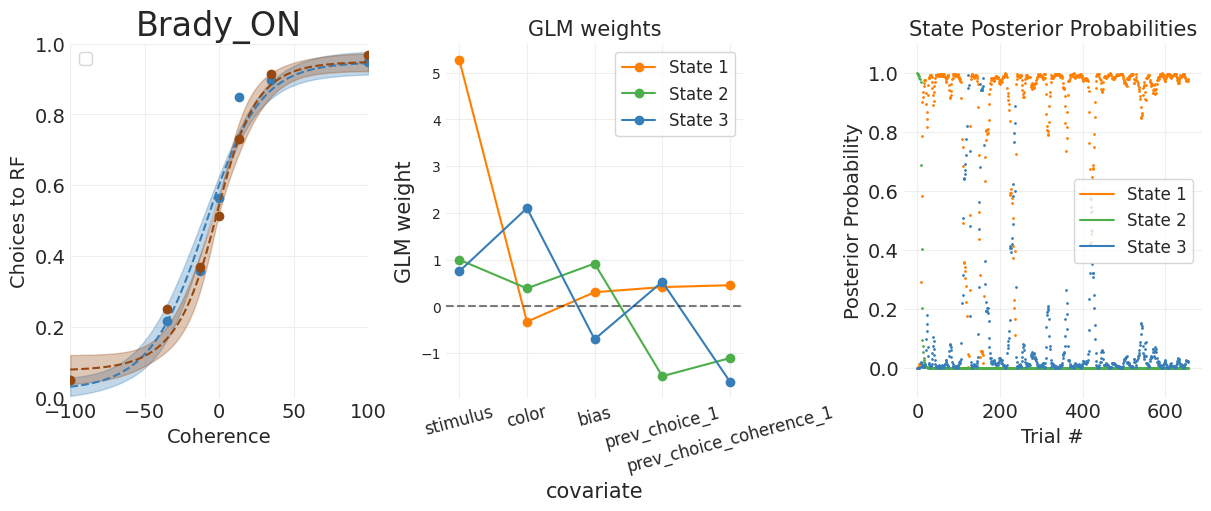

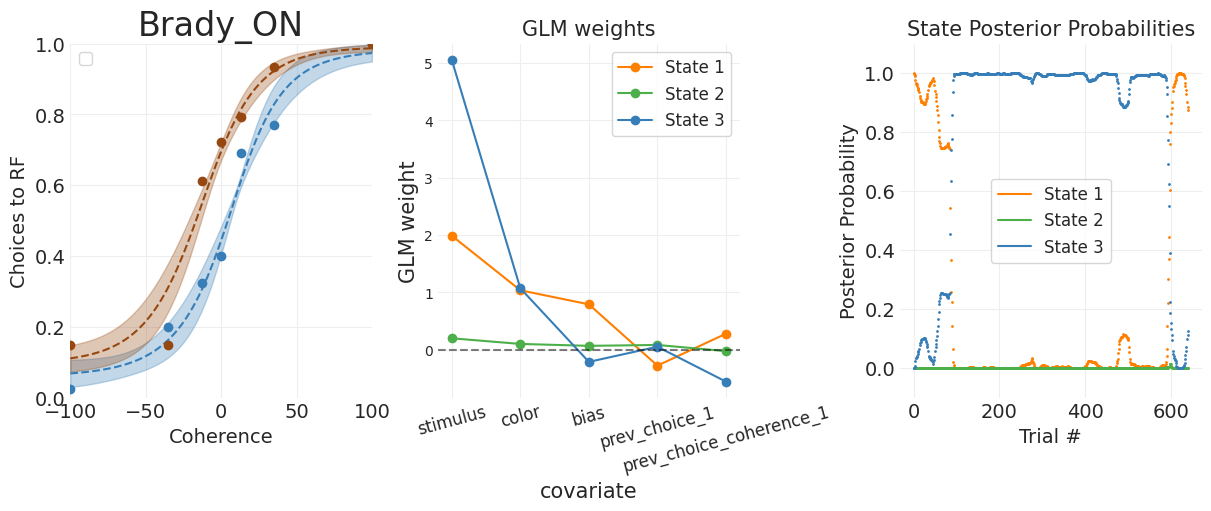

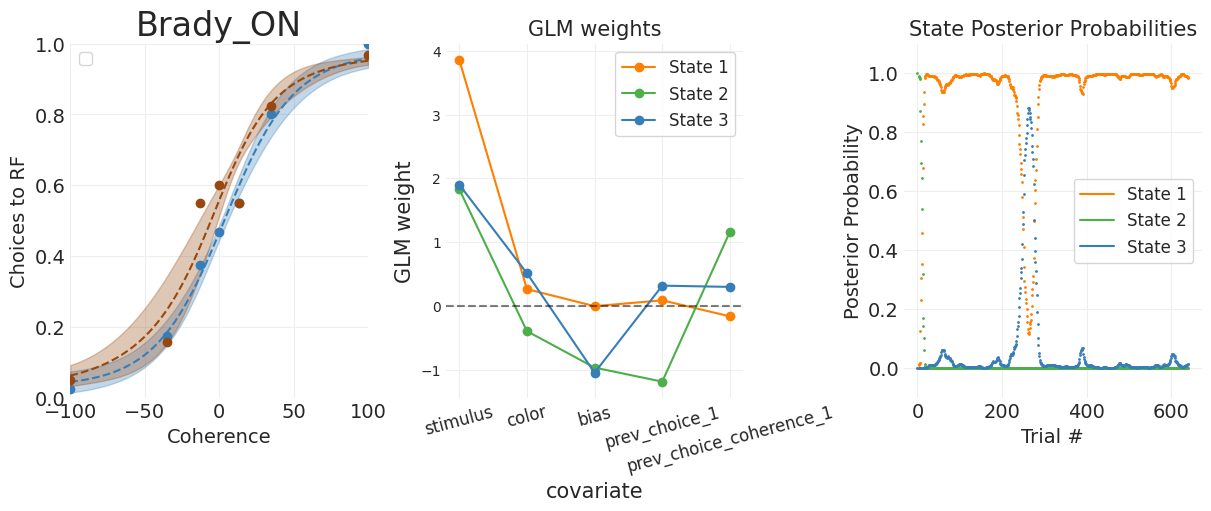

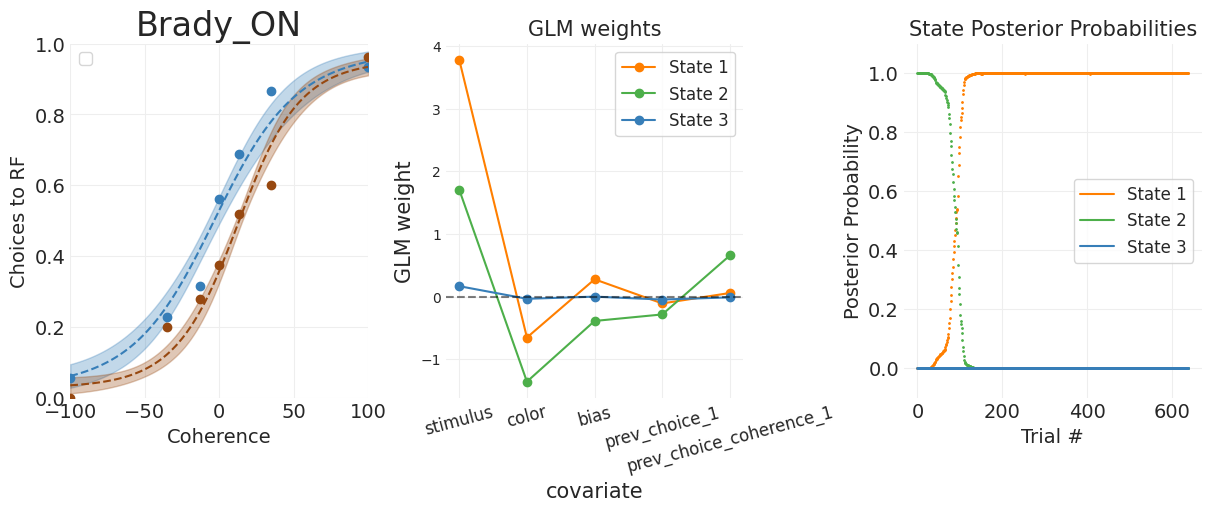

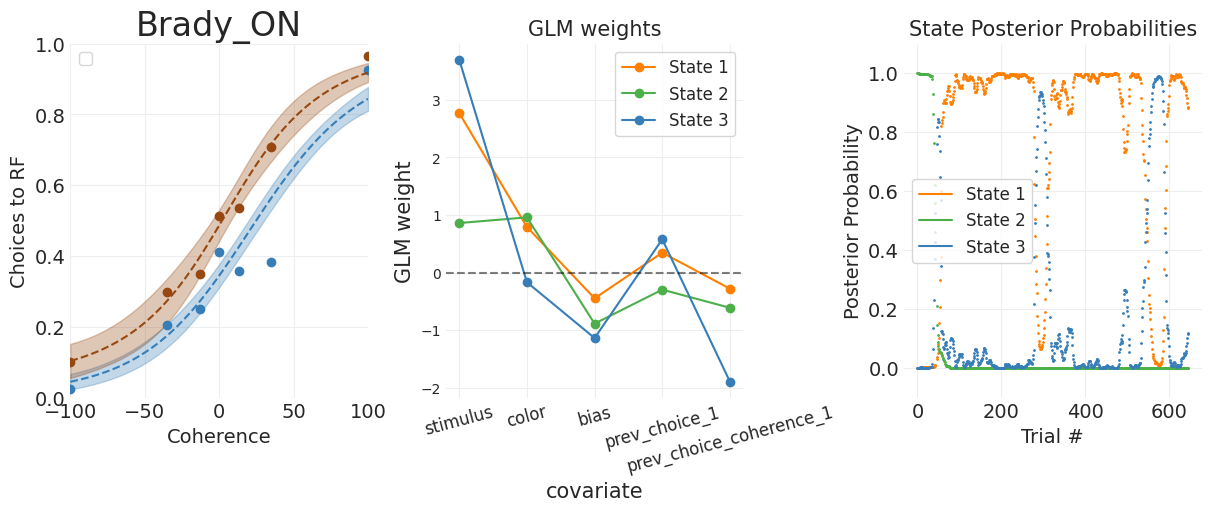

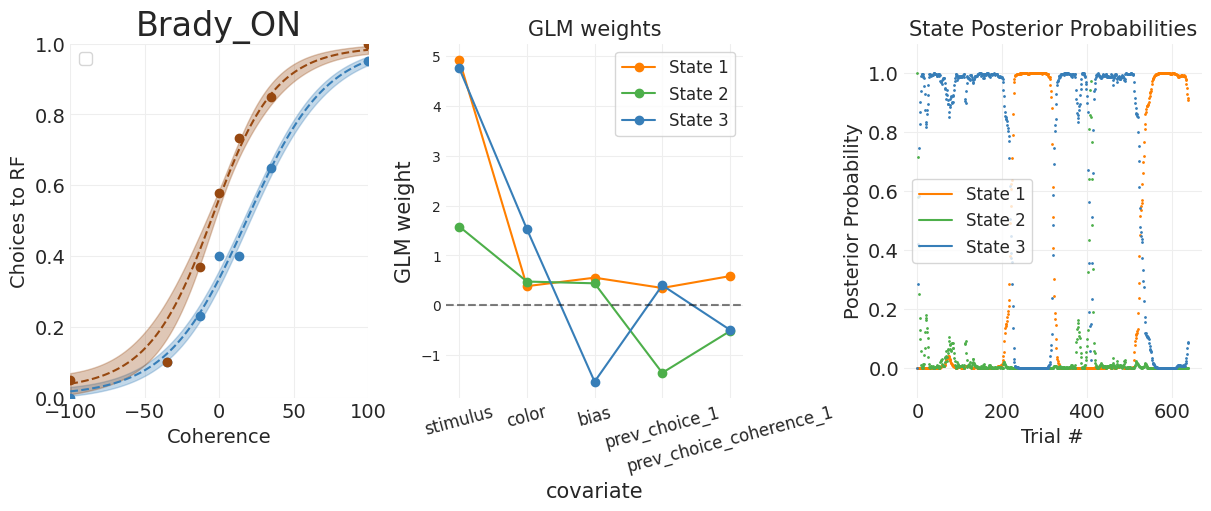

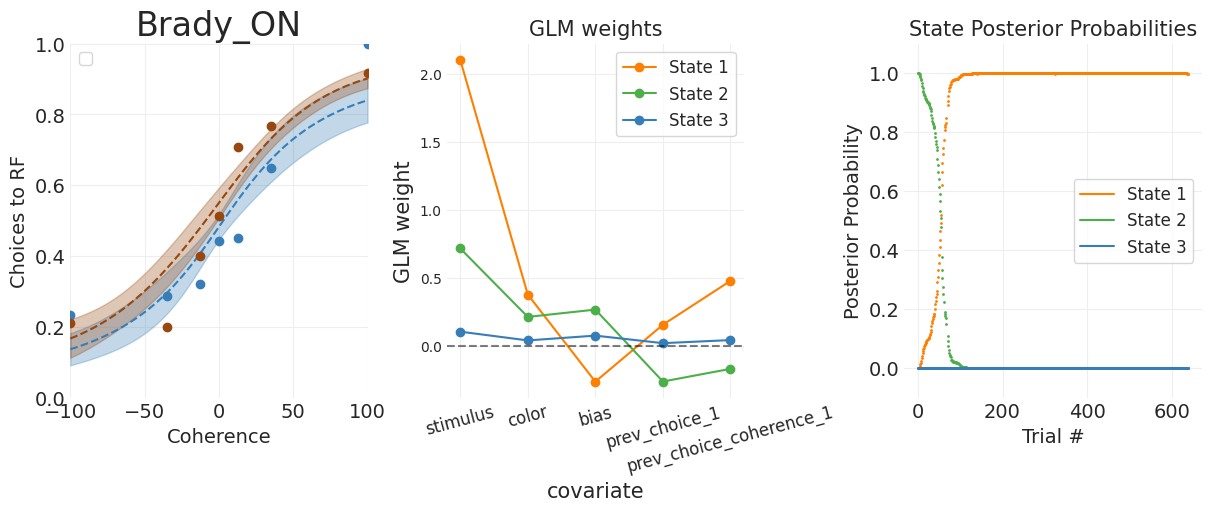

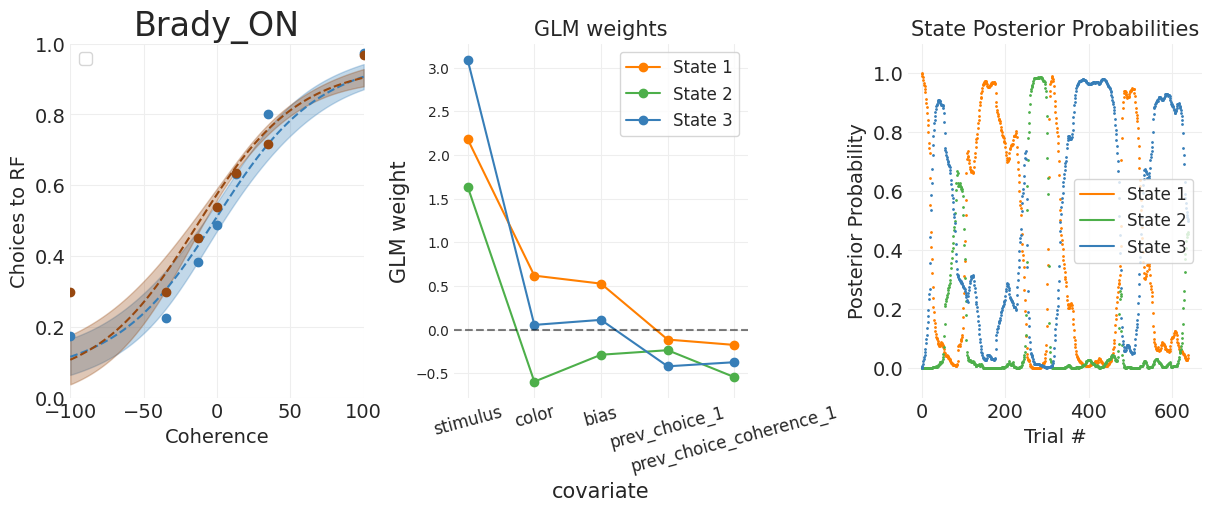

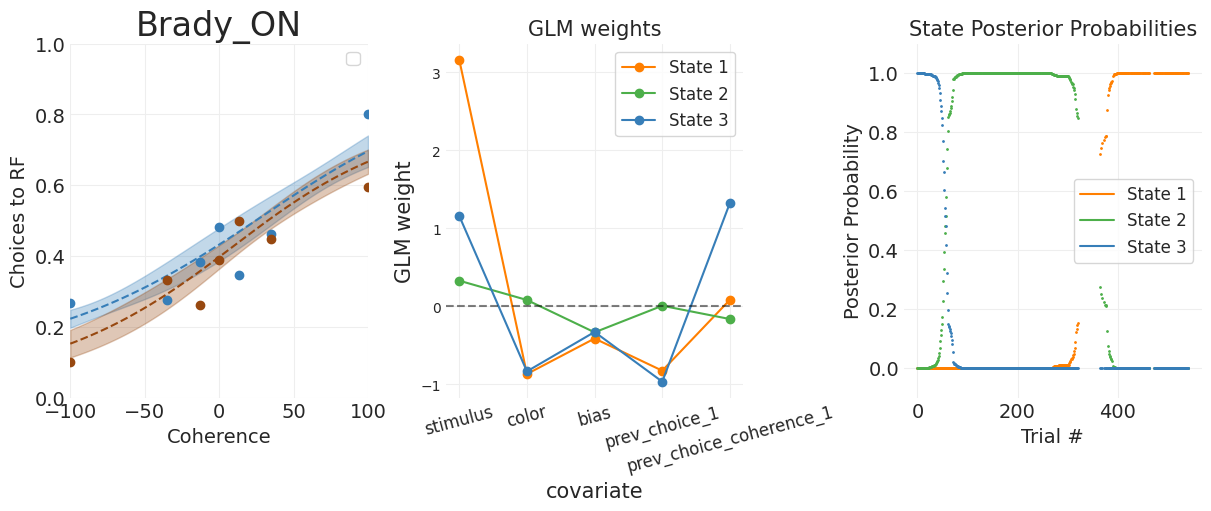

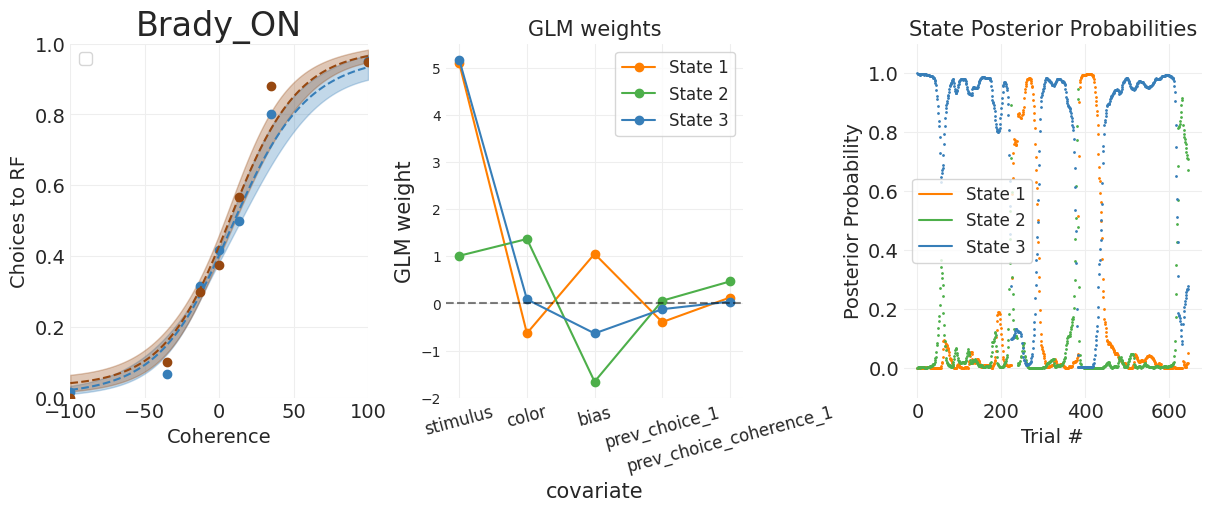

In [13]:
model_path = MODEL_PATHS[selected_model]
cv_type = "pooled_cv" if selected_model.endswith("__global_pooled_cv") else "session_cv"

base_pkls = [p for p in model_path.glob("*.pkl") if p.stem.endswith("_final")]
sorted_pkls = sorted(base_pkls, key=lambda p: order_map.get(p.stem.replace("_final", ""), float("inf")))

for i, subtype_model in tqdm(enumerate(sorted_pkls), total=len(sorted_pkls), desc=f"Processing {selected_model}"):
    group_name = subtype_model.stem[: -len("_final")]
    if subtype_model.stat().st_size == 0:
        print(f"  ! skipping empty/corrupt pickle (needs refitting): {selected_model}/{subtype_model.name}")
        continue
    with open(subtype_model, "rb") as f:
        grp_file = pickle.load(f)

    models = grp_file["model"]["models"]
    glm_data = grp_file["data"]
    config = grp_file["config"]


    for session_id in grp_file["data"].keys():
        _, glm_session_df = get_session_data(session_id, behavior_df, glm_data, config)
        predicted_df = get_expected_state_choice_prob(models[session_id], glm_session_df, config)
        mse, results = compute_psychometric_fits(predicted_df)

        fig, axs = plt.subplots(1, 3, figsize=(12, 5))
        plot_psychometric_fits(results, title=f"{group_name_mapping_to_data.get(group_name, group_name)}", ax=axs[0])
        plot_model_params(models[session_id], config, axs[1])
        plot_state_prob(predicted_df, axs[2])
        plt.show()